UPDATES TO DO:

1. Create scaling for supply with different CF. Baseilne is CF_PV =  0.132 and CF_Wind =  0.347. Pay attention to the max it can go, so normalised output doesn't exceed 1
2. Create function defintions for economics. NPV, LCOH, IRR, PayBackTime, etc. POther functions for system modelling?
3. Define net Margin for sales prices? I.e., how much I profit (comes on top of LCOH)?
4. Function converting H2 (MWh <-> kg)

Imports

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
from oemof import solph
from oemof.solph import processing, views
from oemof.tools import economics
import matplotlib as mpl
from Parameters import parameters as par
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import brentq
import matplotlib.ticker as mticker
import numpy_financial as npf
from datetime import datetime
from collections import defaultdict

Raw Profiles Configuration

In [3]:
DATA_DIR = Path.cwd()   # ← point to your directory
data_path = (DATA_DIR.parent
    / "[02] Data"
    / "Supply")

pv_file = data_path / "ninja_pv_51.9244_4.4778_corrected.csv"
wind_file = data_path / "ninja_wind_51.9244_4.4778_corrected.csv"


df_pv = pd.read_csv(pv_file, sep=",", skiprows=3)
df_pv = df_pv[["time", "electricity"]].copy()
df_pv["electricity"] = pd.to_numeric(df_pv["electricity"], errors="coerce")
df_pv = df_pv.dropna(subset=["electricity"])
df_pv["time"] = pd.to_datetime(df_pv["time"], format="%Y-%m-%d %H:%M")
df_pv = df_pv.sort_values("time")

print("PV profile loaded:", len(df_pv), "rows")

df_wind = pd.read_csv(wind_file, sep=",", skiprows=3)
df_wind = df_wind[["time", "electricity"]].copy()
df_wind["electricity"] = pd.to_numeric(df_wind["electricity"], errors="coerce")
df_wind = df_wind.dropna(subset=["electricity"])
df_wind["time"] = pd.to_datetime(df_wind["time"], format="%Y-%m-%d %H:%M")
df_wind = df_wind.sort_values("time")
print("Wind profile loaded:", len(df_wind), "rows")

 
# ── H2 demand ───────────────────────────────────────────────────
# (absolute, MWh per hour, 8760 rows)
demand_file = (
    DATA_DIR.parent
    / "[02] Data"
    / "Demand"
    / "Demand_Profiles.csv")

df_h2 = pd.read_csv(demand_file, sep=";")
df_h2["Datetime (UTC)"] = pd.to_datetime(df_h2["Datetime (UTC)"], format="%d/%m/%Y %H:%M")
df_h2 = df_h2[["Datetime (UTC)", "Rotterdam_total_gas_demand [MWh]"]].copy()
df_h2["Rotterdam_total_gas_demand [MWh]"] = pd.to_numeric(df_h2["Rotterdam_total_gas_demand [MWh]"], errors="coerce")
df_h2 = df_h2.dropna(subset=["Rotterdam_total_gas_demand [MWh]"])
df_h2 = df_h2.sort_values("Datetime (UTC)").reset_index(drop=True)
demand_h2 = df_h2["Rotterdam_total_gas_demand [MWh]"].values
print("Demand profile loaded:", len(df_h2), "rows")



timeseries = pd.DataFrame({
    "PV": df_pv["electricity"].values,
    "Wind": df_wind["electricity"].values,
    "H2_Demand": demand_h2
}, index=df_h2["Datetime (UTC)"])

# Fix the index
timeseries.index = pd.DatetimeIndex(timeseries.index).round("h")
timeseries.index.name = "time"
timeseries = timeseries.asfreq("h")


print("\nTimeseries DataFrame created successfully:")
print(timeseries.iloc[0:15])
print("\nTimeseries DataFrame info:")
timeseries.info()
print(timeseries.index.freq)

PV profile loaded: 8760 rows
Wind profile loaded: 8760 rows
Demand profile loaded: 8760 rows

Timeseries DataFrame created successfully:
                        PV   Wind   H2_Demand
time                                         
2023-01-01 00:00:00  0.000  0.452  107.470543
2023-01-01 01:00:00  0.000  0.483  104.911918
2023-01-01 02:00:00  0.000  0.505  100.924888
2023-01-01 03:00:00  0.000  0.538   97.491002
2023-01-01 04:00:00  0.000  0.590  101.364114
2023-01-01 05:00:00  0.000  0.611  113.859941
2023-01-01 06:00:00  0.000  0.636  140.369282
2023-01-01 07:00:00  0.000  0.630  175.249485
2023-01-01 08:00:00  0.000  0.602  211.017042
2023-01-01 09:00:00  0.021  0.548  244.047460
2023-01-01 10:00:00  0.135  0.519  249.854811
2023-01-01 11:00:00  0.214  0.526  233.619988
2023-01-01 12:00:00  0.352  0.556  224.990428
2023-01-01 13:00:00  0.281  0.551  219.266315
2023-01-01 14:00:00  0.118  0.546  221.541706

Timeseries DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 

Input Data Validation - Wind


Data path: c:\Users\Gonçalo\Desktop\Projeto_Energetico\[02] Data\Supply
Max calculated power: 1.0
Max given power: 0.984

Selected day data:
                     electricity  wind_speed  power_calc
time                                                    
2019-06-01 00:00:00        0.152       5.294    0.171418
2019-06-01 01:00:00        0.163       5.425    0.184461
2019-06-01 02:00:00        0.169       5.483    0.190441
2019-06-01 03:00:00        0.172       5.518    0.194111
2019-06-01 04:00:00        0.167       5.466    0.188675
2019-06-01 05:00:00        0.117       4.876    0.133936
2019-06-01 06:00:00        0.090       4.511    0.106053
2019-06-01 07:00:00        0.077       4.316    0.092886
2019-06-01 08:00:00        0.062       4.057    0.077147
2019-06-01 09:00:00        0.053       3.872    0.067067
2019-06-01 10:00:00        0.046       3.739    0.060391
2019-06-01 11:00:00        0.041       3.634    0.055445
2019-06-01 12:00:00        0.039       3.604    0.054083
2019

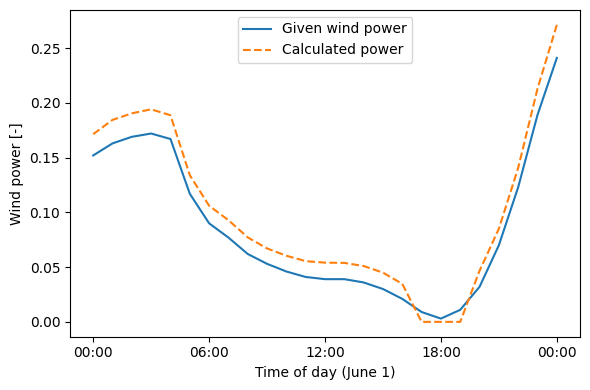

In [4]:
# =====================================================
# ================= Load Data =========================
# =====================================================
DATA_DIR = Path.cwd()   # ← point to your directory
data_path = (DATA_DIR.parent
    / "[02] Data"
    / "Supply")


print(f"Data path: {data_path}")

wind_validation = data_path / "ninja_wind_51.9244_4.4778_corrected.csv"


df_wind_validation = pd.read_csv(wind_validation, sep=",", skiprows=3)

df_wind_validation = df_wind_validation[["time", "electricity", "wind_speed"]].copy()

df_wind_validation["electricity"] = pd.to_numeric(df_wind_validation["electricity"], errors="coerce")
df_wind_validation["wind_speed"] = pd.to_numeric(df_wind_validation["wind_speed"], errors="coerce")

df_wind_validation = df_wind_validation.dropna(subset=["electricity", "wind_speed"])

df_wind_validation["time"] = pd.to_datetime(df_wind_validation["time"], format="%Y-%m-%d %H:%M")
df_wind_validation = df_wind_validation.sort_values("time").set_index("time")



# =====================================================
# ================= Turbine Model ======================
# =====================================================
#Source:
# https://en.wind-turbine-models.com/turbines/16-vestas-v90

rho = 1.225
rotor_r = 45
A = np.pi * rotor_r**2

v_cut_in = 3
v_rated = 12
v_cut_out = 25
P_rated = 2000  # kW


def calc_power(v):
    if v < v_cut_in or v >= v_cut_out:
        return 0
    elif v < v_rated:
        return min(0.593 * 0.5 * rho * A * v**3 / 1000/ P_rated, 1)
    else:
        return 1


# =====================================================
# ============ Compute Power ===========================
# =====================================================

df_wind_validation["power_calc"] = df_wind_validation["wind_speed"].apply(calc_power)


# =====================================================
# ============ Select One Day ==========================
# =====================================================

chosen_date = "2019-06-01" # try "2023-07-01", "2023-01-01" and "2023-11-06"
start = pd.to_datetime(chosen_date)
end = start + pd.Timedelta(days=1)
print("Max calculated power:", df_wind_validation["power_calc"].max())
print("Max given power:", df_wind_validation["electricity"].max())
# Select full day INCLUDING next midnight
wind_validation_day = df_wind_validation.loc[start:end].copy()

print("\nSelected day data:")
print(wind_validation_day)


# =====================================================
# ============ Common Date Formatting =================
# =====================================================

locator = mdates.HourLocator(byhour=[0, 6, 12, 18])
formatter = mdates.DateFormatter("%H:%M")


# =====================================================
# ================= Plot ==============================
# =====================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_wind_validation.loc[start:end].index,
        df_wind_validation.loc[start:end]["electricity"],
        label="Given wind power")

ax.plot(df_wind_validation.loc[start:end].index,
        df_wind_validation.loc[start:end]["power_calc"],
        linestyle="--",
        label="Calculated power")

ax.set_ylabel(r"Wind power [-]")

#ax.set_xlabel(f"Time of day ({chosen_date})")
# Convert to datetime object
dt = datetime.strptime(chosen_date, "%Y-%m-%d")
# Format as "Month day" (e.g., "November 6")
formatted_date = dt.strftime("%B %#d") 
ax.set_xlabel(f"Time of day ({formatted_date})")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)


ax.legend(loc="upper center")   # <-- add this line


# =====================================================
# ================= Save Figure =======================
# =====================================================

figures_path = DATA_DIR.parent.parent / "[03] Figures"
figures_path.mkdir(exist_ok=True)

output_file = figures_path / "wind_power_validation.pdf"

plt.tight_layout()
#plt.savefig(output_file, bbox_inches="tight")
print(f"Figure saved to: {output_file}")
plt.show()

OEMOF Model Setup - Creating Buses and Units

In [ ]:
# =============================================================================
# OEMOF MODEL SETUP
# =============================================================================

# Create energy system
energysystem = solph.EnergySystem(timeindex=timeseries.index, infer_last_interval=True)

# Create buses
bus_electricity = solph.Bus(label='electricity')
bus_H2 = solph.Bus(label='hydrogen')

# Create components 

pv = solph.components.Source(
    label="pv",
    outputs={bus_electricity: solph.Flow(
        fix=timeseries["PV"],
        nominal_value=solph.Investment(
                ep_costs=par.PV_CAPEX/par.PV_LIFETIME_SYSTEM + par.PV_OPEX,  # annualized CAPEX in €/MW/year and OPEX (same units)
                minimum=0,
                existing=0
            ),
        variable_costs=0 #OPEX isn't here because it is a fixed cost for this unit, given in €/MW/year 
        )
    },)


wind = solph.components.Source(
    label="wind",
    outputs={bus_electricity: solph.Flow(
        fix=timeseries["Wind"],
        nominal_value=solph.Investment(
                ep_costs=par.WIND_CAPEX/par.WIND_LIFETIME_SYSTEM + par.WIND_OPEX,  # annualized CAPEX in €/MW/year and OPEX (same units)
                minimum=0,
                existing=0
            ),
        variable_costs=0 #OPEX isn't here because it is a fixed cost for this unit, given in €/MW/year 
        )
    },)

'''print("PV Annuity:", economics.annuity(par.PV_CAPEX, par.PV_LIFETIME_SYSTEM, 0.05))
print("Wind Annuity:", economics.annuity(par.WIND_CAPEX, par.WIND_LIFETIME_SYSTEM, 0.05))'''


electrolyser = solph.components.Converter(
    label="electrolyser",
    inputs={bus_electricity: solph.Flow(
        nominal_value=solph.Investment(
            ep_costs=par.ELECTROLYSER_CAPEX/par.ELECTROLYSER_LIFETIME_SYSTEM  
                    + par.ELECTROLYSER_OPEX,  # €/MW/year
            minimum=0,
            existing=0,
        ),
        # min=par.ELECTROLYSER_MIN_LOAD,  # TODO: Requires unit commitment logic; disabled for now
        variable_costs=0,
    )},
    outputs={bus_H2: solph.Flow()},
    conversion_factors={bus_H2: par.ELECTROLYSER_EFFICIENCY},
)


battery = solph.components.GenericStorage(
    label="battery",
    inputs={
        bus_electricity: solph.Flow()
    },
    outputs={
        bus_electricity: solph.Flow()
    },
    nominal_storage_capacity=solph.Investment(
        ep_costs=par.BATTERY_CAPEX/20 + par.BATTERY_OPEX_FIX,  # €/MWh/year (annualized CAPEX + fixed OPEX)
        minimum=0,
        existing=0
    ),
    storage_costs = par.BATTERY_OPEX_VAR,       # €/MWh (Cost (per energy) for having energy in the storage.)
    loss_rate=par.BATTERY_SELF_DISCHARGE_RATE,
    initial_storage_level=0,
    inflow_conversion_factor=par.BATTERY_EFFICIENCY_CHARGE,
    outflow_conversion_factor=par.BATTERY_EFFICIENCY_DISCHARGE,
    invest_relation_input_capacity=1/par.BATTERY_MIN_CHARGE_TIME,  # C-rate 0.25 (4h for full charge)
    invest_relation_output_capacity=1/par.BATTERY_MIN_DISCHARGE_TIME, 
)



saltcavern = solph.components.GenericStorage(
    label="saltcavern",
    inputs={
        bus_H2: solph.Flow() #par.SALTCAVERN_CAPEX_POWER should come here when incorporating compressor costs, but for now we assume no cost for charge/discharge power, only for storage capacity

    },
    outputs={
        bus_H2: solph.Flow()
    },
    nominal_storage_capacity=solph.Investment(
        ep_costs=par.SALTCAVERN_CAPEX/par.SALTCAVERN_LIFETIME + par.SALTCAVERN_OPEX,  # €/MWh/year (annualized CAPEX + fixed OPEX)
        minimum=0,
        existing=0
    ),
    storage_costs = 0,       # €/MWh (Cost (per energy) for having energy in the storage.) No cost for storing H2 in salt cavern, only for the capacity
    loss_rate=0,  # Assuming no self-discharge for salt cavern storage
    initial_storage_level=0,
    inflow_conversion_factor=1,
    outflow_conversion_factor=par.SALTCAVERN_EFFICIENCY,
)

#TODO: finish input and output flow definitions for salt cavern when incorporating costs. 
#Then, costs should be added to the input only, to avoid double-counting the cost of storage capacity (which is the same for input and output flows since it's a storage cost, not a power flow cost). 
'''inputs={bus_H2: solph.Flow(
        nominal_value=solph.Investment(
            ep_costs=par.SALTCAVERN_CAPEX_POWER/par.SALTCAVERN_LIFETIME + par.SALTCAVERN_OPEX_POWER,  # €/MW/year
            minimum=0,
        )
    )},
    outputs={bus_H2: solph.Flow(
        nominal_value=solph.Investment(
            ep_costs=0,  # avoid double-counting power cost
            minimum=0,
        )
    )},'''



H2Demand = solph.components.Sink(
    label="H2_demand",
    inputs={
        bus_H2: solph.Flow(
            fix=timeseries["H2_Demand"],
            nominal_value=1,  # No investment decision for demand, so nominal_value is set to 1
            variable_costs=0  # No variable cost for demand
        )
    }
)


# Dump sink for excess electricity (exports, curtailment, or other uses)
# This prevents infeasibility by allowing excess renewable production to be disposed of
electricity_curtailement = solph.components.Sink(
    label="electricity_curtailement",
    inputs={
        bus_electricity: solph.Flow(
            variable_costs=0  # Free to curtail (or use a small cost if preferred)
        )
    }
)


print("Max H2 demand (MWh/h):", timeseries["H2_Demand"].max())
print("ELECTROLYSER_EFFICIENCY:", par.ELECTROLYSER_EFFICIENCY)
print("PV ep_costs:", par.PV_CAPEX / par.PV_LIFETIME_SYSTEM + par.PV_OPEX)



Max H2 demand (MWh/h): 770.6940466
ELECTROLYSER_EFFICIENCY: 0.65
PV ep_costs: 39564.0


Solving System

In [ ]:

# Add components to energy system
energysystem.add(bus_electricity, bus_H2, pv, wind, electrolyser, H2Demand, battery, saltcavern, electricity_curtailement)

model = solph.Model(energysystem)
model.solve(
    solver='cbc',
    solve_kwargs={'tee': True}  # Mostra progresso
)


print("Processando resultados...\n")

resultados = solph.processing.results(model)
string_results = views.convert_keys_to_strings(resultados)

# See all keys (all flows in the model)
# ===== EXTRAIR CAPACIDADES ÓTIMAS =====

# PV
capacidade_pv = resultados[(pv, bus_electricity)]['scalars']['invest']

# Wind
capacidade_wind = resultados[(wind, bus_electricity)]['scalars']['invest']


# Electrolyser
capacidade_electrolyser_input = resultados[(bus_electricity, electrolyser)]['scalars']['invest']


print("="*90)
print("🎯 RESULTADOS DA OTIMIZAÇÃO")
print("="*90)
print("\n💡 CAPACIDADES ÓTIMAS:")
print(f"  PV: {capacidade_pv:.1f} MW")
print(f"  Wind: {capacidade_wind:.1f} MW")
print(f"  Electrolyser (electricity Input): {capacidade_electrolyser_input:.1f} MW")
print(f"  Total Renovável: {capacidade_pv + capacidade_wind:.1f} MW")

# Battery capacity (if battery is included)
try:
    capacidade_battery = resultados[(battery, None)]['scalars']['invest']
    print(f"  Battery: {capacidade_battery:.1f} MWh")
except KeyError:
    print("  Battery: Not included in model")


# Salt cavern capacity (if saltcavern is included)
try:
    capacidade_saltcavern = resultados[(saltcavern, None)]['scalars']['invest']
    print(f"  Salt Cavern: {capacidade_saltcavern:.1f} MWh")
except KeyError:
    print("  Salt Cavern: Not included in model")


Welcome to the CBC MILP Solver 
Version: 2.10.11 
Build Date: Oct 25 2023 

command line - C:\CBC\bin\cbc.exe -printingOptions all -import C:\Users\GONALO~1\AppData\Local\Temp\tmpuxohe5j_.pyomo.lp -stat=1 -solve -solu C:\Users\GONALO~1\AppData\Local\Temp\tmpuxohe5j_.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 78830 (-26303) rows, 61313 (-35063) columns and 223106 (-61376) elements
Statistics for presolved model


Problem has 78830 rows, 61313 columns (5 with objective) and 223106 elements
Column breakdown:
61312 of type 0.0->inf, 1 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
17516 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
8758 of type E other, 8758 of type G 0.0, 0 of type G 1.0, 
2 of type G other, 43794 of type L 0.0, 0 of type L 1.0, 
2 of type L other, 0 of type Range 0.0->1.0, 0 of type Range other, 
0 

Organize Results for Post-processing

In [ ]:
# =============================================================================
# VISUALISATION
# =============================================================================
print(resultados[(battery, None)]['sequences'].columns)
print(resultados[(saltcavern, None)]['sequences'].columns)
# ── Extract timeseries from results ──────────────────────────────────────────

pv_flow       = resultados[(pv, bus_electricity)]['sequences']['flow']
wind_flow     = resultados[(wind, bus_electricity)]['sequences']['flow']
el_input      = resultados[(bus_electricity, electrolyser)]['sequences']['flow']
el_output     = resultados[(electrolyser, bus_H2)]['sequences']['flow']
h2_demand_ts  = resultados[(bus_H2, H2Demand)]['sequences']['flow']
curtailment   = resultados[(bus_electricity, electricity_curtailement)]['sequences']['flow']
battery_soc   = resultados[(battery, None)]['sequences']['storage_content']
bat_charge    = resultados[(bus_electricity, battery)]['sequences']['flow']
bat_discharge = resultados[(battery, bus_electricity)]['sequences']['flow']
saltcavern_soc   = resultados[(saltcavern, None)]['sequences']['storage_content']
saltcavern_charge    = resultados[(bus_H2, saltcavern)]['sequences']['flow']
saltcavern_discharge = resultados[(saltcavern, bus_H2)]['sequences']['flow']

# Drop the last row (oemof adds an extra timestep due to infer_last_interval)
idx = pv_flow.index[:-1]
pv_flow       = pv_flow.iloc[:-1]
wind_flow     = wind_flow.iloc[:-1]
el_input      = el_input.iloc[:-1]
el_output     = el_output.iloc[:-1]
h2_demand_ts  = h2_demand_ts.iloc[:-1]
curtailment   = curtailment.iloc[:-1]
battery_soc   = battery_soc.iloc[:-1]
bat_charge    = bat_charge.iloc[:-1]
bat_discharge = bat_discharge.iloc[:-1]
saltcavern_soc   = saltcavern_soc.iloc[:-1]
saltcavern_charge    = saltcavern_charge.iloc[:-1]
saltcavern_discharge = saltcavern_discharge.iloc[:-1]



Index(['storage_content'], dtype='object', name='variable_name')
Index(['storage_content'], dtype='object', name='variable_name')


PLOT 1 — Annual energy flows (monthly aggregated for readability)

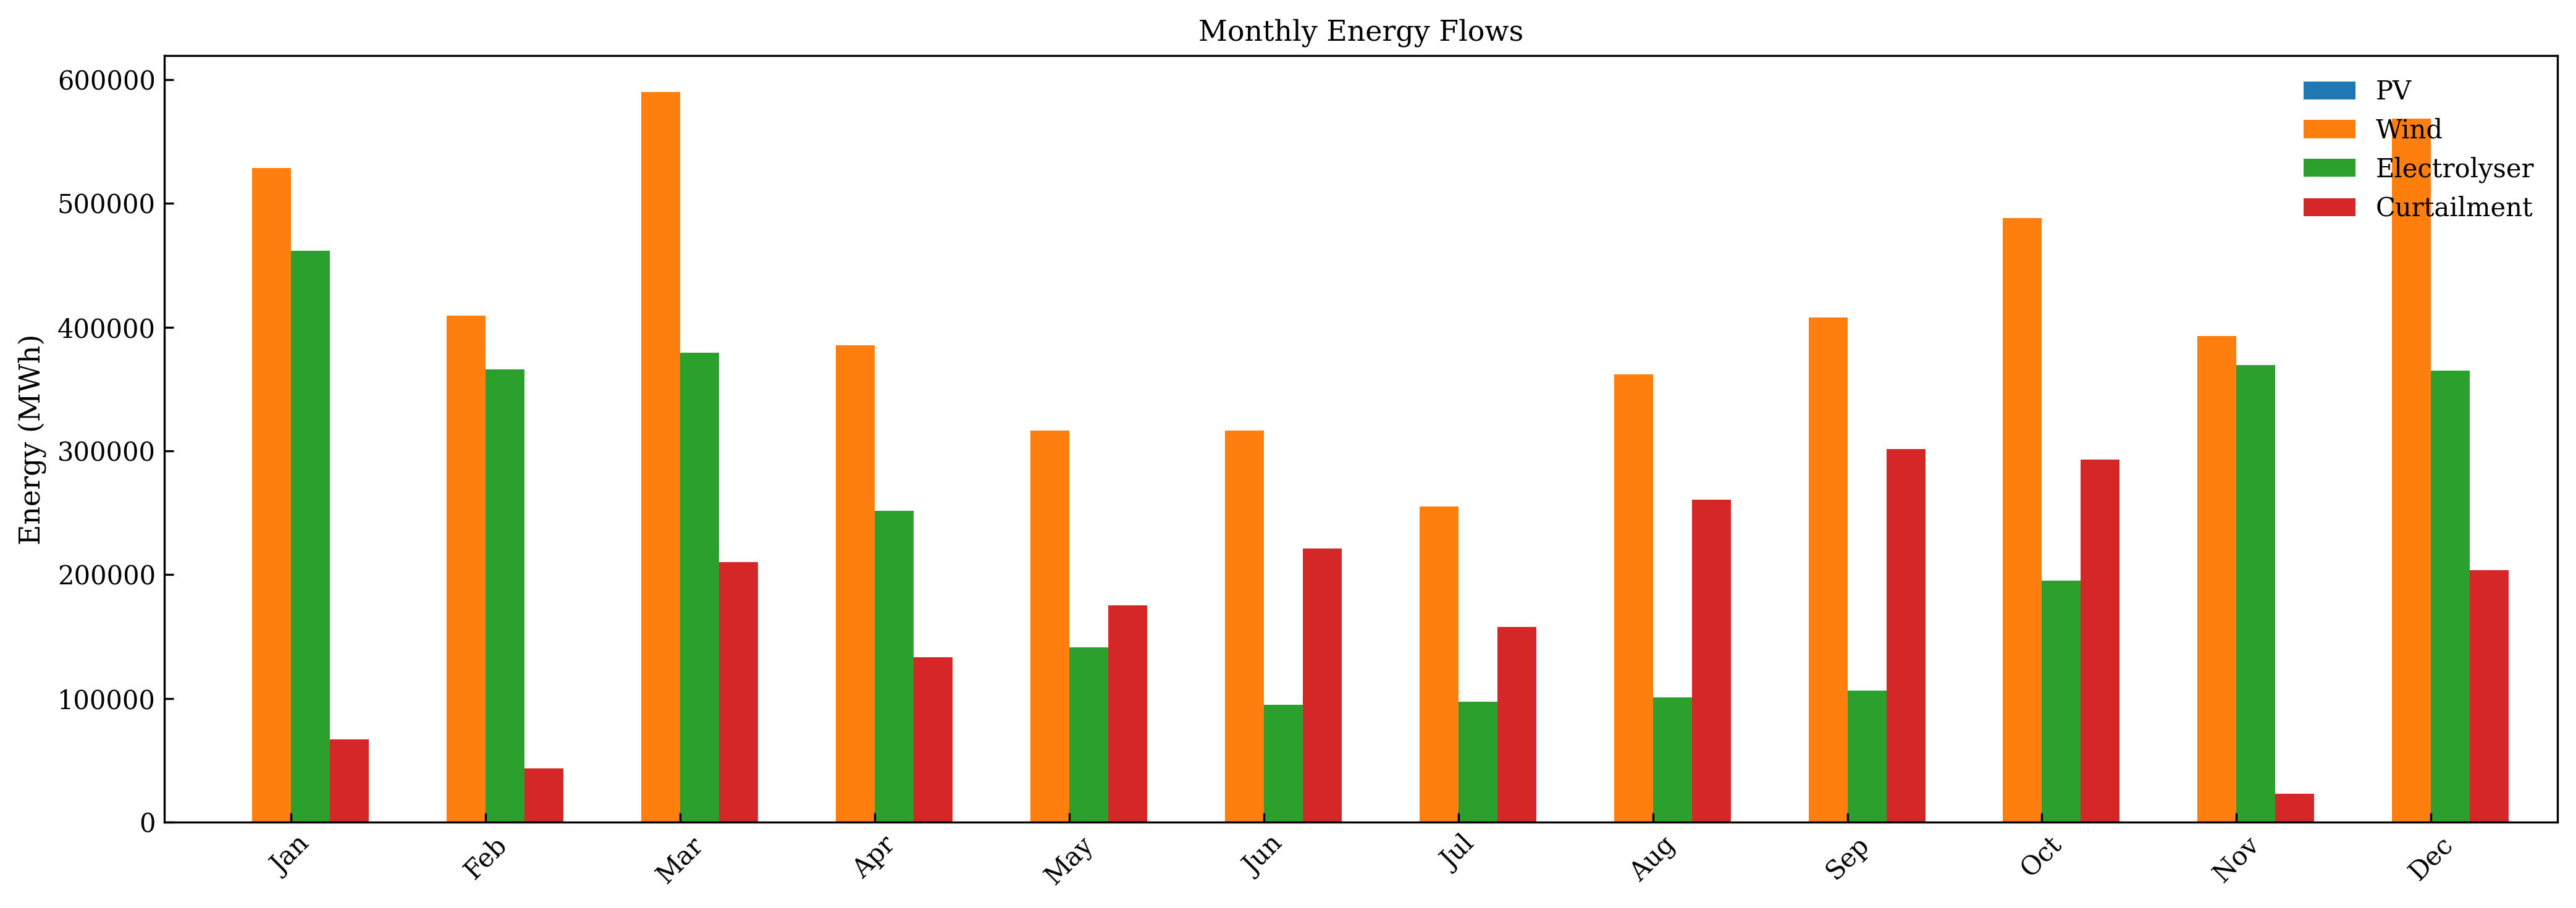

In [ ]:
monthly = pd.DataFrame({
    "PV":          pv_flow.values,
    "Wind":        wind_flow.values,
    "Electrolyser":el_input.values,
    "Curtailment": curtailment.values,
    "H2 Demand":   h2_demand_ts.values,
}, index=idx).resample("ME").sum()

fig, ax = plt.subplots(figsize=(14, 5))
monthly[["PV", "Wind", "Electrolyser", "Curtailment"]].plot(
    kind="bar", ax=ax, width=0.8
)
ax.set_title("Monthly Energy Flows")
ax.set_ylabel("Energy (MWh)")
ax.set_xlabel("")
ax.set_xticklabels([d.strftime("%b") for d in monthly.index], rotation=45)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("CAVERN_monthly_flows.pdf", dpi=150)
plt.show()


PLOT 2 — Sample week: hourly dispatch

In [ ]:
# Pick a representative summer week (July)
week_start = "2023-07-10"
week_end   = "2023-07-17"
sl = slice("2023-07-10", "2023-07-17")

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

# Electricity bus
axes[0].fill_between(pv_flow.loc[sl].index,   pv_flow.loc[sl].values,   label="PV",   alpha=0.7)
axes[0].fill_between(wind_flow.loc[sl].index, wind_flow.loc[sl].values, label="Wind", alpha=0.7)
axes[0].plot(el_input.loc[sl].index,    el_input.loc[sl].values,    label="Electrolyser input", color="black", lw=1.5)
axes[0].plot(curtailment.loc[sl].index, curtailment.loc[sl].values, label="Curtailment",        color="red",   lw=1, ls="--")
axes[0].set_ylabel("MW")
axes[0].set_title("Electricity Bus — Sample Week")
axes[0].legend(loc="upper right")

# H2 bus
axes[1].plot(el_output.loc[sl].index,    el_output.loc[sl].values,    label="H2 produced", color="green",  lw=1.5)
axes[1].plot(h2_demand_ts.loc[sl].index, h2_demand_ts.loc[sl].values, label="H2 demand",   color="orange", lw=1.5, ls="--")
axes[1].set_ylabel("MWh/h")
axes[1].set_title("H2 Bus — Sample Week")
axes[1].legend(loc="upper right")

# Battery SOC
axes[2].fill_between(battery_soc.loc[sl].index, battery_soc.loc[sl].values, alpha=0.5, color="purple", label="Battery SOC")
axes[2].plot(bat_charge.loc[sl].index,    bat_charge.loc[sl].values,    label="Charging",    color="blue", lw=1)
axes[2].plot(bat_discharge.loc[sl].index, bat_discharge.loc[sl].values, label="Discharging", color="red",  lw=1)
axes[2].set_ylabel("MWh")
axes[2].set_title("Battery — Sample Week")
axes[2].legend(loc="upper right")

# Salt cavern SOC
axes[3].fill_between(saltcavern_soc.loc[sl].index, saltcavern_soc.loc[sl].values, alpha=0.5, color="brown", label="Salt Cavern SOC")
axes[3].plot(saltcavern_charge.loc[sl].index,    saltcavern_charge.loc[sl].values,    label="Injection",  color="blue", lw=1)
axes[3].plot(saltcavern_discharge.loc[sl].index, saltcavern_discharge.loc[sl].values, label="Withdrawal", color="red",  lw=1)
axes[3].set_ylabel("MWh")
axes[3].set_title("Salt Cavern — Sample Week")
axes[3].legend(loc="upper right")

axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.savefig("CAVERN_sample_week_dispatch.png", dpi=150)
plt.show()




PLOT 3 — Full year electrolyser load duration curve

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Top: chronological electrolyser load across 2023
axes[0].plot(el_input.index, el_input.values, color="red", lw=0.8)
axes[0].axhline(capacidade_electrolyser_input, color="black", ls="--", lw=1, label="Installed capacity")
axes[0].set_title("Electrolyser Load — 2023")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("MW")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].legend()

# Bottom: load duration curve
sorted_load = el_input.sort_values(ascending=False).values
axes[1].plot(sorted_load, color="steelblue", lw=1.5)
axes[1].axhline(capacidade_electrolyser_input, color="black", ls="--", lw=1, label="Installed capacity")
axes[1].set_title("Electrolyser Load Duration Curve — 2023")
axes[1].set_xlabel("Hours per year (ranked)")
axes[1].set_ylabel("MW")
axes[1].legend()

plt.tight_layout()
plt.savefig("CAVERN_load_duration_curve.png", dpi=150)
plt.show()

PLOT 4 — Full year Battery SOC

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(battery_soc.index, battery_soc.values, alpha=0.5, color="purple")
ax.set_title("Battery State of Charge — Full Year")
ax.set_ylabel("MWh")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.savefig("CAVERN_battery_soc_year.png", dpi=150)
plt.show()

 PLOT 5 — Sensitivity: PV vs Wind installed capacity, cost and LCOH2 heatmaps

In [ ]:
# =============================================================================
# Sweeps PV and Wind CAPEX, records optimal installed capacities,
# total system cost, and LCOH2
# =============================================================================

pv_costs   = np.linspace(par.PV_CAPEX   * 0.5, par.PV_CAPEX   * 1.5, 6)
wind_costs = np.linspace(par.WIND_CAPEX * 0.5, par.WIND_CAPEX * 1.5, 6)

pv_cap_grid   = np.zeros((len(pv_costs), len(wind_costs)))
wind_cap_grid = np.zeros((len(pv_costs), len(wind_costs)))
cost_grid     = np.zeros((len(pv_costs), len(wind_costs)))
lcoh2_grid    = np.zeros((len(pv_costs), len(wind_costs)))

total_h2_produced = timeseries["H2_Demand"].sum()  # MWh H2 per year (fixed demand, always met)

for i, pv_c in enumerate(pv_costs):
    for j, wind_c in enumerate(wind_costs):

        es   = solph.EnergySystem(timeindex=timeseries.index, infer_last_interval=True)
        b_el = solph.Bus(label='electricity')
        b_h2 = solph.Bus(label='hydrogen')

        pv_s = solph.components.Source(label="pv", outputs={b_el: solph.Flow(
            fix=timeseries["PV"],
            nominal_value=solph.Investment(
                ep_costs=pv_c/par.PV_LIFETIME_SYSTEM + par.PV_OPEX))})

        wind_s = solph.components.Source(label="wind", outputs={b_el: solph.Flow(
            fix=timeseries["Wind"],
            nominal_value=solph.Investment(
                ep_costs=wind_c/par.WIND_LIFETIME_SYSTEM + par.WIND_OPEX))})

        el_s = solph.components.Converter(label="electrolyser",
            inputs={b_el: solph.Flow(nominal_value=solph.Investment(
                ep_costs=par.ELECTROLYSER_CAPEX/par.ELECTROLYSER_LIFETIME_SYSTEM + par.ELECTROLYSER_OPEX))},
            outputs={b_h2: solph.Flow()},
            conversion_factors={b_h2: par.ELECTROLYSER_EFFICIENCY})

        bat_s = solph.components.GenericStorage(label="battery",
            inputs={b_el: solph.Flow()}, outputs={b_el: solph.Flow()},
            nominal_storage_capacity=solph.Investment(
                ep_costs=par.BATTERY_CAPEX/20 + par.BATTERY_OPEX_FIX),
            loss_rate=par.BATTERY_SELF_DISCHARGE_RATE,
            inflow_conversion_factor=par.BATTERY_EFFICIENCY_CHARGE,
            outflow_conversion_factor=par.BATTERY_EFFICIENCY_DISCHARGE,
            invest_relation_input_capacity=1/par.BATTERY_MIN_CHARGE_TIME,
            invest_relation_output_capacity=1/par.BATTERY_MIN_DISCHARGE_TIME)

        dem  = solph.components.Sink(label="H2_demand", inputs={b_h2: solph.Flow(
            fix=timeseries["H2_Demand"], nominal_value=1)})
        curtail = solph.components.Sink(label="electricity_curtailement", inputs={b_el: solph.Flow()})

        es.add(b_el, b_h2, pv_s, wind_s, el_s, bat_s, dem, curtail)
        m = solph.Model(es)
        m.solve(solver='cbc', solve_kwargs={'tee': False})
        res = solph.processing.results(m)

        pv_cap   = res[(pv_s, b_el)]['scalars']['invest']
        wind_cap = res[(wind_s, b_el)]['scalars']['invest']
        tot_cost = m.objective()
        lcoh2    = tot_cost / total_h2_produced  # €/MWh H2

        pv_cap_grid[i, j]   = pv_cap
        wind_cap_grid[i, j] = wind_cap
        cost_grid[i, j]     = tot_cost
        lcoh2_grid[i, j]    = lcoh2

        print(f"  PV={pv_c:.0f}, Wind={wind_c:.0f} → PV={pv_cap:.0f} MW, Wind={wind_cap:.0f} MW, Cost={tot_cost:.0f} €/yr, LCOH2={lcoh2:.2f} €/MWh")


# ── Build axis labels: optimal PV and Wind capacities (averaged across the sweep) ──
# Since each cell has a unique (pv_cap, wind_cap), we use the mean capacity
# per row/column as axis tick labels

pv_cap_labels   = np.round(pv_cap_grid.mean(axis=1), 0).astype(int)   # mean wind cap per PV cost row
wind_cap_labels = np.round(wind_cap_grid.mean(axis=0), 0).astype(int) # mean PV cap per wind cost col


# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Total system cost
sns.heatmap(
    cost_grid / 1e6,  # convert to M€/yr for readability
    xticklabels=wind_cap_labels,
    yticklabels=pv_cap_labels,
    annot=True, fmt=".1f",
    ax=axes[0],
    cmap="RdYlGn_r",
    cbar_kws={"label": "Total Annualised Cost (M€/yr)"}
)
axes[0].set_title("Total System Cost (M€/yr)")
axes[0].set_xlabel("Optimal Wind Capacity (MW)")
axes[0].set_ylabel("Optimal PV Capacity (MW)")

# Heatmap 2: LCOH2
sns.heatmap(
    lcoh2_grid,
    xticklabels=wind_cap_labels,
    yticklabels=pv_cap_labels,
    annot=True, fmt=".1f",
    ax=axes[1],
    cmap="RdYlGn_r",
    cbar_kws={"label": "LCOH2 (€/MWh H2)"}
)
axes[1].set_title("Levelised Cost of Hydrogen (€/MWh H₂)")
axes[1].set_xlabel("Optimal Wind Capacity (MW)")
axes[1].set_ylabel("Optimal PV Capacity (MW)")

plt.suptitle("Sensitivity Analysis: PV vs Wind CAPEX Sweep", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("CAVERN_sensitivity_cost_lcoh2.png", dpi=150, bbox_inches="tight")
plt.show()

Define Plotting Defintions

In [ ]:
# =====================================================
# ========== TU Delft Thesis-Compatible Styling =======
# =====================================================

mpl.rcParams.update({

    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",

    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",

    "lines.linewidth": 1.0,

    "legend.frameon": False,

    "figure.dpi": 300,
    "savefig.format": "pdf"
})


Raw Profiles Configuration

In [11]:
DATA_DIR = Path.cwd()   # ← point to your directory
data_path = (DATA_DIR.parent
    / "[02] Data"
    / "Supply")

pv_file = data_path / "ninja_pv_51.9244_4.4778_corrected.csv"
wind_file = data_path / "ninja_wind_51.9244_4.4778_corrected.csv"


df_pv = pd.read_csv(pv_file, sep=",", skiprows=3)
df_pv = df_pv[["time", "electricity"]].copy()
df_pv["electricity"] = pd.to_numeric(df_pv["electricity"], errors="coerce")
df_pv = df_pv.dropna(subset=["electricity"])
df_pv["time"] = pd.to_datetime(df_pv["time"], format="%Y-%m-%d %H:%M")
df_pv = df_pv.sort_values("time")

print("PV profile loaded:", len(df_pv), "rows")

df_wind = pd.read_csv(wind_file, sep=",", skiprows=3)
df_wind = df_wind[["time", "electricity"]].copy()
df_wind["electricity"] = pd.to_numeric(df_wind["electricity"], errors="coerce")
df_wind = df_wind.dropna(subset=["electricity"])
df_wind["time"] = pd.to_datetime(df_wind["time"], format="%Y-%m-%d %H:%M")
df_wind = df_wind.sort_values("time")
print("Wind profile loaded:", len(df_wind), "rows")

 
# ── H2 demand ───────────────────────────────────────────────────
# (absolute, MWh per hour, 8760 rows)
demand_file = (
    DATA_DIR.parent
    / "[02] Data"
    / "Demand"
    / "Demand_Profiles.csv")

df_h2 = pd.read_csv(demand_file, sep=";")
df_h2["Datetime (UTC)"] = pd.to_datetime(df_h2["Datetime (UTC)"], format="%d/%m/%Y %H:%M")
df_h2 = df_h2[["Datetime (UTC)", "Rotterdam_total_gas_demand [MWh]"]].copy()
df_h2["Rotterdam_total_gas_demand [MWh]"] = pd.to_numeric(df_h2["Rotterdam_total_gas_demand [MWh]"], errors="coerce")
df_h2 = df_h2.dropna(subset=["Rotterdam_total_gas_demand [MWh]"])
df_h2 = df_h2.sort_values("Datetime (UTC)").reset_index(drop=True)
demand_h2 = df_h2["Rotterdam_total_gas_demand [MWh]"].values
print("Demand profile loaded:", len(df_h2), "rows")



timeseries = pd.DataFrame({
    "PV": df_pv["electricity"].values,
    "Wind": df_wind["electricity"].values,
    "H2_Demand": demand_h2
}, index=df_h2["Datetime (UTC)"])

# Fix the index
timeseries.index = pd.DatetimeIndex(timeseries.index).round("h")
timeseries.index.name = "time"
timeseries = timeseries.asfreq("h")


print("\nTimeseries DataFrame created successfully:")
print(timeseries.iloc[0:15])
print("\nTimeseries DataFrame info:")
timeseries.info()
print(timeseries.index.freq)

PV profile loaded: 8760 rows
Wind profile loaded: 8760 rows
Demand profile loaded: 8760 rows

Timeseries DataFrame created successfully:
                        PV   Wind   H2_Demand
time                                         
2023-01-01 00:00:00  0.000  0.452  107.470543
2023-01-01 01:00:00  0.000  0.483  104.911918
2023-01-01 02:00:00  0.000  0.505  100.924888
2023-01-01 03:00:00  0.000  0.538   97.491002
2023-01-01 04:00:00  0.000  0.590  101.364114
2023-01-01 05:00:00  0.000  0.611  113.859941
2023-01-01 06:00:00  0.000  0.636  140.369282
2023-01-01 07:00:00  0.000  0.630  175.249485
2023-01-01 08:00:00  0.000  0.602  211.017042
2023-01-01 09:00:00  0.021  0.548  244.047460
2023-01-01 10:00:00  0.135  0.519  249.854811
2023-01-01 11:00:00  0.214  0.526  233.619988
2023-01-01 12:00:00  0.352  0.556  224.990428
2023-01-01 13:00:00  0.281  0.551  219.266315
2023-01-01 14:00:00  0.118  0.546  221.541706

Timeseries DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 

Input Data Validation - Wind


Data path: c:\Users\Gonçalo\Desktop\Projeto_Energetico\[02] Data\Supply
Max calculated power: 1.0
Max given power: 0.984

Selected day data:
                     electricity  wind_speed  power_calc
time                                                    
2019-06-01 00:00:00        0.152       5.294    0.171418
2019-06-01 01:00:00        0.163       5.425    0.184461
2019-06-01 02:00:00        0.169       5.483    0.190441
2019-06-01 03:00:00        0.172       5.518    0.194111
2019-06-01 04:00:00        0.167       5.466    0.188675
2019-06-01 05:00:00        0.117       4.876    0.133936
2019-06-01 06:00:00        0.090       4.511    0.106053
2019-06-01 07:00:00        0.077       4.316    0.092886
2019-06-01 08:00:00        0.062       4.057    0.077147
2019-06-01 09:00:00        0.053       3.872    0.067067
2019-06-01 10:00:00        0.046       3.739    0.060391
2019-06-01 11:00:00        0.041       3.634    0.055445
2019-06-01 12:00:00        0.039       3.604    0.054083
2019

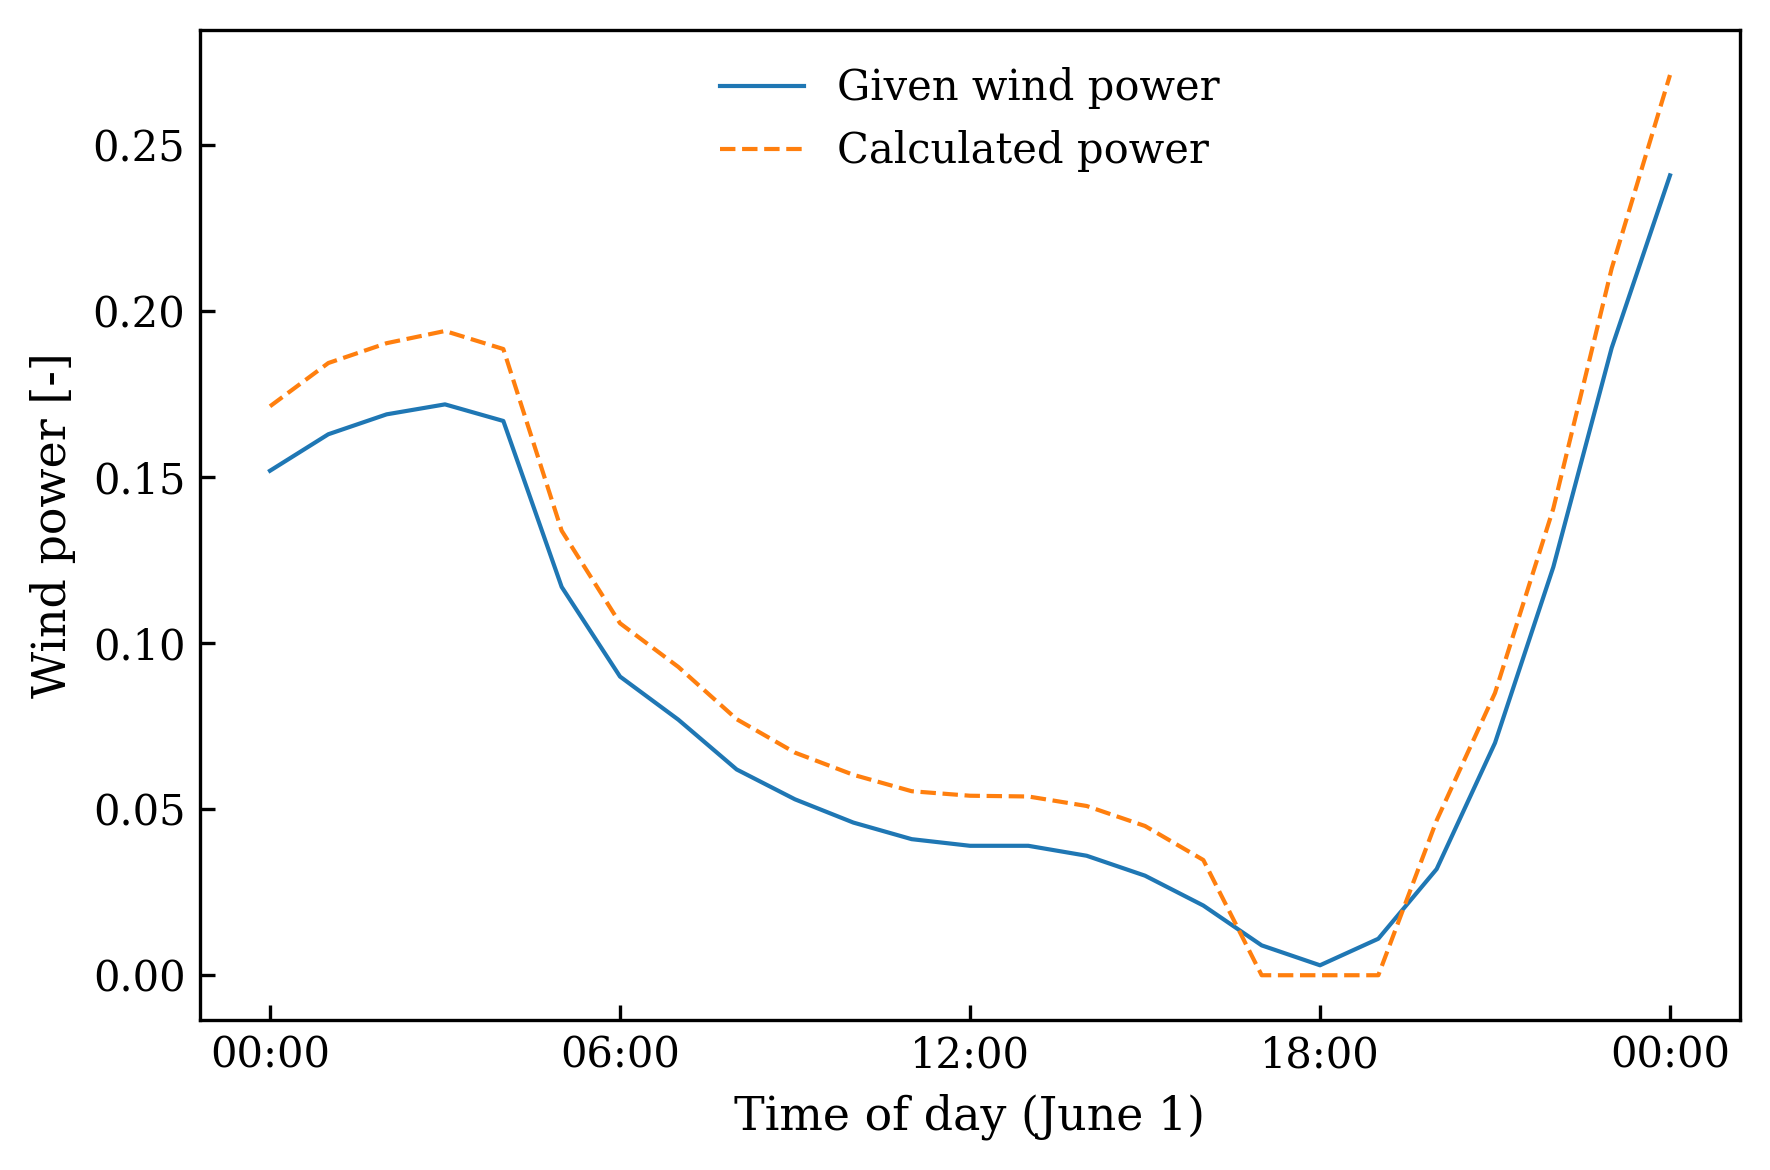

In [ ]:
# =====================================================
# ================= Load Data =========================
# =====================================================
DATA_DIR = Path.cwd()   # ← point to your directory
data_path = (DATA_DIR.parent
    / "[02] Data"
    / "Supply")


print(f"Data path: {data_path}")

wind_validation = data_path / "ninja_wind_51.9244_4.4778_corrected.csv"


df_wind_validation = pd.read_csv(wind_validation, sep=",", skiprows=3)

df_wind_validation = df_wind_validation[["time", "electricity", "wind_speed"]].copy()

df_wind_validation["electricity"] = pd.to_numeric(df_wind_validation["electricity"], errors="coerce")
df_wind_validation["wind_speed"] = pd.to_numeric(df_wind_validation["wind_speed"], errors="coerce")

df_wind_validation = df_wind_validation.dropna(subset=["electricity", "wind_speed"])

df_wind_validation["time"] = pd.to_datetime(df_wind_validation["time"], format="%Y-%m-%d %H:%M")
df_wind_validation = df_wind_validation.sort_values("time").set_index("time")



# =====================================================
# ================= Turbine Model ======================
# =====================================================
#Source:
# https://en.wind-turbine-models.com/turbines/16-vestas-v90

rho = 1.225
rotor_r = 45
A = np.pi * rotor_r**2

v_cut_in = 3
v_rated = 12
v_cut_out = 25
P_rated = 2000  # kW


def calc_power(v):
    if v < v_cut_in or v >= v_cut_out:
        return 0
    elif v < v_rated:
        return min(0.593 * 0.5 * rho * A * v**3 / 1000/ P_rated, 1)
    else:
        return 1


# =====================================================
# ============ Compute Power ===========================
# =====================================================

df_wind_validation["power_calc"] = df_wind_validation["wind_speed"].apply(calc_power)


# =====================================================
# ============ Select One Day ==========================
# =====================================================

chosen_date = "2019-06-01" # try "2023-07-01", "2023-01-01" and "2023-11-06"
start = pd.to_datetime(chosen_date)
end = start + pd.Timedelta(days=1)
print("Max calculated power:", df_wind_validation["power_calc"].max())
print("Max given power:", df_wind_validation["electricity"].max())
# Select full day INCLUDING next midnight
wind_validation_day = df_wind_validation.loc[start:end].copy()

print("\nSelected day data:")
print(wind_validation_day)


# =====================================================
# ============ Common Date Formatting =================
# =====================================================

locator = mdates.HourLocator(byhour=[0, 6, 12, 18])
formatter = mdates.DateFormatter("%H:%M")


# =====================================================
# ================= Plot ==============================
# =====================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_wind_validation.loc[start:end].index,
        df_wind_validation.loc[start:end]["electricity"],
        label="Given wind power")

ax.plot(df_wind_validation.loc[start:end].index,
        df_wind_validation.loc[start:end]["power_calc"],
        linestyle="--",
        label="Calculated power")

ax.set_ylabel(r"Wind power [-]")

#ax.set_xlabel(f"Time of day ({chosen_date})")
# Convert to datetime object
dt = datetime.strptime(chosen_date, "%Y-%m-%d")
# Format as "Month day" (e.g., "November 6")
formatted_date = dt.strftime("%B %#d") 
ax.set_xlabel(f"Time of day ({formatted_date})")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)


ax.legend(loc="upper center")   # <-- add this line


# =====================================================
# ================= Save Figure =======================
# =====================================================

figures_path = DATA_DIR.parent.parent / "[03] Figures"
figures_path.mkdir(exist_ok=True)

output_file = figures_path / "wind_power_validation.pdf"

plt.tight_layout()
#plt.savefig(output_file, bbox_inches="tight")
print(f"Figure saved to: {output_file}")
plt.show()

Input Data Validation - PV

Data path: c:\Users\Gonçalo\Desktop\Projeto_Energetico\[02] Data\Supply

Selected day data:
                     electricity  irradiance_direct  irradiance_diffuse  \
time                                                                      
2019-06-01 00:00:00        0.000              0.000               0.000   
2019-06-01 01:00:00        0.000              0.000               0.000   
2019-06-01 02:00:00        0.000              0.000               0.000   
2019-06-01 03:00:00        0.000              0.000               0.003   
2019-06-01 04:00:00        0.019              0.000               0.042   
2019-06-01 05:00:00        0.074              0.038               0.069   
2019-06-01 06:00:00        0.224              0.188               0.093   
2019-06-01 07:00:00        0.363              0.334               0.120   
2019-06-01 08:00:00        0.494              0.498               0.133   
2019-06-01 09:00:00        0.593              0.641               0.139   
2019-06-

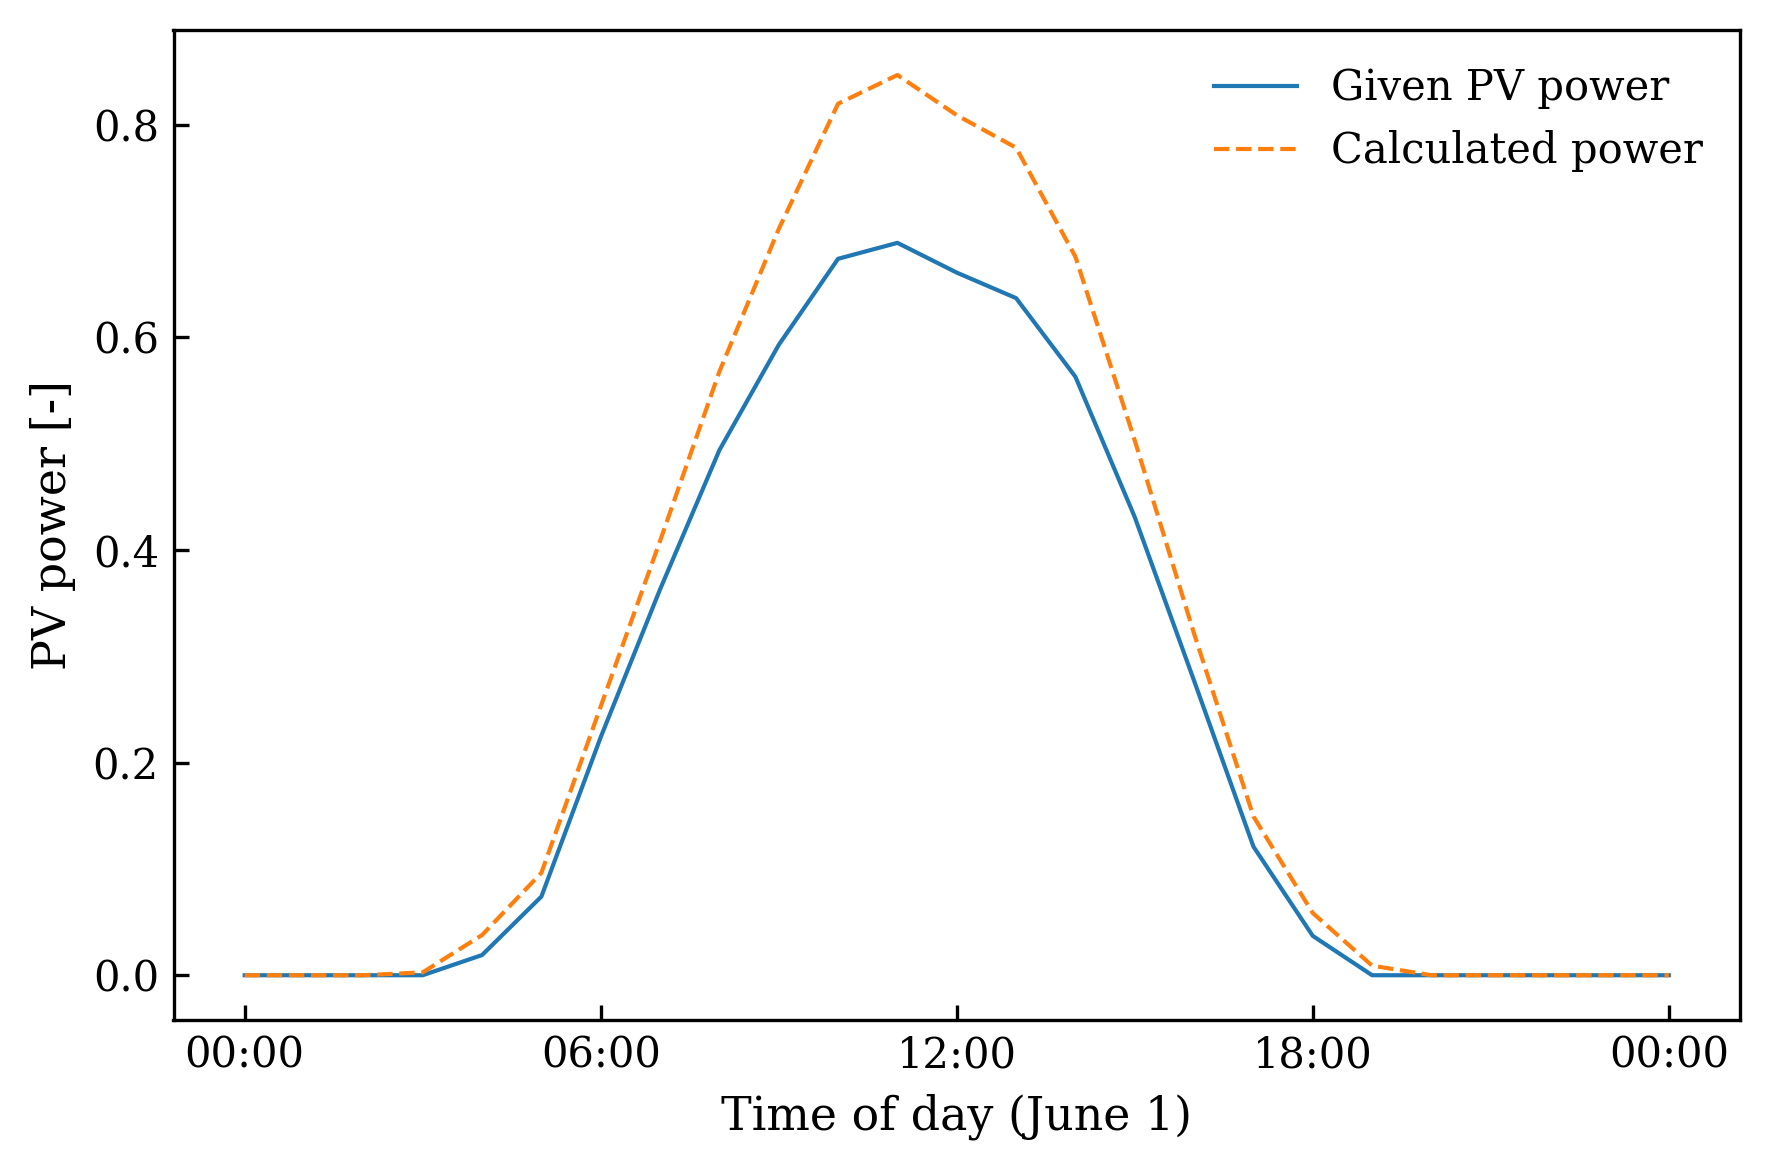

In [ ]:
# =====================================================
# ================= Load Data =========================
# =====================================================
DATA_DIR = Path.cwd()   # ← point to your directory
data_path = (DATA_DIR.parent
    / "[02] Data"
    / "Supply")


print(f"Data path: {data_path}")

pv_validation = data_path / "ninja_pv_51.9244_4.4778_corrected.csv"


pv_validation = pd.read_csv(pv_validation, sep=",", skiprows=3)

pv_validation = pv_validation[["time", "electricity", "irradiance_direct", "irradiance_diffuse"]].copy()

for col in ["electricity", "irradiance_direct", "irradiance_diffuse"]:
    pv_validation[col] = pd.to_numeric(pv_validation[col], errors="coerce")

pv_validation = pv_validation.dropna(subset=["electricity", "irradiance_direct", "irradiance_diffuse"])

pv_validation["time"] = pd.to_datetime(pv_validation["time"], format="%Y-%m-%d %H:%M")
pv_validation = pv_validation.sort_values("time").set_index("time")




# =====================================================
# ================= PV Model ======================
# =====================================================

P_max = 1000            # Wp per panel
eta_module = 0.255

# Define number of panels (you MUST set this)
n_panels = 1   # <-- CHANGE THIS to your real value

# Panel area (m²)
panel_area = P_max / (eta_module * 1000)  # A = P / (eta * 1000 W/m²)

# POA irradiance (W/m²)
pv_validation["G_poa"] = pv_validation["irradiance_direct"] + pv_validation["irradiance_diffuse"]

# Physical PV per panel (kW)
pv_validation["power_calc"] = pv_validation["G_poa"]  *0.9 # W → kW

# RN per panel (assuming electricity is total system kW)
pv_validation["power_given"] = pv_validation["electricity"] 


# =====================================================
# ============ Select One Day ==========================
# =====================================================

chosen_date = "2019-06-01" # try "2023-07-01", "2023-01-01" and "2023-11-06"
start = pd.to_datetime(chosen_date)
end = start + pd.Timedelta(days=1)

# Select full day INCLUDING next midnight
df_pv_validation_day = pv_validation.loc[start:end].copy()

print("\nSelected day data:")
print(df_pv_validation_day)
print("Max calculated power:", df_pv_validation_day["power_calc"].max())
print("Max given power:", df_pv_validation_day["power_given"].max())


# =====================================================
# ============ Common Date Formatting =================
# =====================================================

locator = mdates.HourLocator(byhour=[0, 6, 12, 18])
formatter = mdates.DateFormatter("%H:%M")


# =====================================================
# ================= Plot ==============================
# =====================================================

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_pv_validation_day.index,
        df_pv_validation_day["power_given"],
        label="Given PV power")

ax.plot(df_pv_validation_day.index,
        df_pv_validation_day["power_calc"],
        linestyle="--",
        label="Calculated power")

ax.set_ylabel(r"PV power [-]")
# Convert to datetime object
dt = datetime.strptime(chosen_date, "%Y-%m-%d")
# Format as "Month day" (e.g., "November 6")
formatted_date = dt.strftime("%B %#d") 
ax.set_xlabel(f"Time of day ({formatted_date})")
#ax.set_xlabel(f"Time of day ({chosen_date})")

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
#ax.set_xlim(df_pv_day.index.min(), df_pv_day.index.max())

ax.legend(loc="best")   # <-- add this line

'''# Convert to datetime object
dt = datetime.strptime(chosen_date, "%Y-%m-%d")
# Format as "Month day" (e.g., "November 6")
formatted_date = dt.strftime("%B %#d") 
ax.set_xlabel(f"Time of day ({formatted_date})")
'''

# =====================================================
# ================= Save Figure =======================
# =====================================================

figures_path = DATA_DIR.parent.parent / "[03] Figures"
figures_path.mkdir(exist_ok=True)

output_file = figures_path / "pv_power_validation.pdf"

plt.tight_layout()
#plt.savefig(output_file, bbox_inches="tight")
print(f"Figure saved to: {output_file}")
plt.show()

Function Defintions

In [ ]:
#Techno-economic parameters
discount_rate = par.WACC       # 7%
wacc = par.WACC
lifetime = par.LIFETIME              # years
net_profit_margin = par.MARGIN_H2  # 8.1% 


'''#H2 conversion parameters
F = 96485            # Faraday constant [C/mol]
M_H2 = 2.016e-3      # kg/mol
A_ef = 2             # m^2 does not matter, cancels out
z = 2                # electrons per H2
n_F = 0.95           # Faradaic efficiency
V_cell = 1.8         # stack voltage [V]

SECONDS_PER_HOUR = 3600
dt = SECONDS_PER_HOUR


H2_ENERGY_PER_VOLUME = 9.776 # kWh/m3
H2_ENERGY_PER_MASS = 33.3    # kWh/kg, equiavlent to 120 MJ/kg'''


def NPV(h2_price, H2_used, CAPEX_total, OPEX_annual, stack_costs, discount_rate):
    lifetime_years = len(H2_used)
    years = np.arange(1, lifetime_years + 1)
    annual_cashflow = h2_price * H2_used - OPEX_annual - stack_costs
    discounted_cashflow = np.sum(annual_cashflow / (1 + discount_rate) ** years)
    return discounted_cashflow - CAPEX_total

def LCOH(annual_H2_kg, CAPEX_total, OPEX_annual, stack_costs, discount_rate):
    return brentq(NPV, 0.1, 50.0,
        args=(annual_H2_kg, CAPEX_total, OPEX_annual, stack_costs, discount_rate))


def discounted_payback_time(CAPEX, OPEX, H2_used, h2_price, discount_rate, stack_costs):
  
    cumulative_npv = 0
    year = 0
    
    while cumulative_npv < CAPEX:
        year += 1
        if year > len(H2_used):
            return np.nan  # safety check to prevent infinite loop if H2_used is shorter than lifetime
        cost_stack = stack_costs[year-1] if year <= len(stack_costs) else 0
        annual_cashflow = h2_price * H2_used[year-1] - OPEX - cost_stack
        cumulative_npv += annual_cashflow / (1 + discount_rate) ** year
        
        if year > 100:
            return np.nan
    
    return year

# IRR functie
def build_cashflows(price, H2, CAPEX, OPEX, stack_costs):
    cf = np.zeros(len(H2) + 1)
    cf[0] = -CAPEX
    cf[1:] = price * H2 - OPEX - stack_costs
    return cf

def IRR(price, H2, CAPEX, OPEX, stack_costs):
    cf = build_cashflows(price, H2, CAPEX, OPEX, stack_costs)

    def npv_r(r):
        years = np.arange(len(cf))
        return np.sum(cf / (1 + r) ** years)

    return brentq(npv_r, -0.99, 1.0)  # IRR must be > -100% and < 100%



'''
# Function: H2 production per timestep [mol/s]
def hydrogen_mol_per_s_from_power(P_load_kW):
    P_W = P_load_kW * 1000
    i_cell = np.where(P_W > 0, P_W / (A_ef * V_cell), 0.0)
    I_stack = i_cell * A_ef
    return n_F * I_stack  / (z * F)

# Function: annual H2 production [kg/year]
def annual_h2_from_load(P_load_ts):
    H2_mol_ts = np.array([hydrogen_mol_per_s_from_power(P) for P in P_load_ts])
    H2_kg_ts = H2_mol_ts * M_H2 * dt
    return np.sum(H2_kg_ts)'''


'\n# Function: H2 production per timestep [mol/s]\ndef hydrogen_mol_per_s_from_power(P_load_kW):\n    P_W = P_load_kW * 1000\n    i_cell = np.where(P_W > 0, P_W / (A_ef * V_cell), 0.0)\n    I_stack = i_cell * A_ef\n    return n_F * I_stack  / (z * F)\n\n# Function: annual H2 production [kg/year]\ndef annual_h2_from_load(P_load_ts):\n    H2_mol_ts = np.array([hydrogen_mol_per_s_from_power(P) for P in P_load_ts])\n    H2_kg_ts = H2_mol_ts * M_H2 * dt\n    return np.sum(H2_kg_ts)'

OEMOF Model Setup - Creating Buses and Units

In [26]:

# Create energy system
energysystem = solph.EnergySystem(timeindex=timeseries.index, infer_last_interval=True)

# Create buses
bus_electricity = solph.Bus(label='electricity')
bus_H2 = solph.Bus(label='hydrogen')

# Create components 
# ── PV ───────────────────────────────────────────────────
pv = solph.components.Source(
    label="pv",
    outputs={bus_electricity: solph.Flow(
        fix=timeseries["PV"],
        nominal_value=solph.Investment(
                ep_costs=(
                    economics.annuity(capex = par.PV_CAPEX_PANELS, n=par.PV_LIFETIME_SYSTEM, wacc=par.WACC) 
                    + economics.annuity(capex=par.PV_CAPEX_INVERTER, n= par.PV_LIFETIME_SYSTEM, wacc = par.WACC, u = par.PV_LIFETIME_INVERTER)
                    + par.PV_OPEX), # annualized CAPEX in €/MW/year and OPEX (same units)
                minimum=0,
                existing=0
            ),
        variable_costs=0  
        )
    },)

# ── Wind ───────────────────────────────────────────────────
wind = solph.components.Source(
    label="wind",
    outputs={bus_electricity: solph.Flow(
        fix=timeseries["Wind"],
        nominal_value=solph.Investment(
                ep_costs=economics.annuity(capex=par.WIND_CAPEX, n=par.WIND_LIFETIME_SYSTEM, wacc=par.WACC) + par.WIND_OPEX,  # annualized CAPEX in €/MW/year and OPEX (same units)
                #ep_costs=par.WIND_CAPEX/par.WIND_LIFETIME_SYSTEM + par.WIND_OPEX,  
                existing=0
            ),
        variable_costs=0 #OPEX isn't here because it is a fixed cost for this unit, given in €/MW/year 
        )
    },)

# ── Electrolyser ───────────────────────────────────────────────────
electrolyser = solph.components.Converter(
    label="electrolyser",
    inputs={bus_electricity: solph.Flow(
        nominal_value=solph.Investment(
            ep_costs=(
                    economics.annuity(capex = par.ELECTROLYSER_CAPEX_SYSTEM, n=par.ELECTROLYSER_LIFETIME_SYSTEM, wacc=par.WACC)
                    + economics.annuity(capex = par.ELECTROLYSER_CAPEX_STACK, n=par.ELECTROLYSER_LIFETIME_SYSTEM, wacc=par.WACC, u=par.ELECTROLYSER_LIFETIME_STACK)
                    + par.ELECTROLYSER_OPEX ),  # annualized CAPEX for system and stack
            minimum=0,
            existing=0,
        ),
        min=par.ELECTROLYSER_MIN_LOAD,  # TODO: Requires unit commitment logic; disabled for now
        variable_costs=0, #€/MWh
    )},
    outputs={bus_H2: solph.Flow()}, #, bus_heat:solph.Flow()
    conversion_factors={bus_H2: par.ELECTROLYSER_EFFICIENCY}, #, bus_heat: par.ELECTROLYSER_RECOVERABLE_HEAT
)

# ── Battery ───────────────────────────────────────────────────
battery = solph.components.GenericStorage(
    label="battery",
    inputs={
        bus_electricity: solph.Flow(
            nominal_value=solph.Investment(
                #par.BATTERY_CAPEX_POWER = 0. It's defined simply for consistency and future-proofing when incorporating power-related costs, but for now we assume no cost for charge/discharge power, only for storage capacity.
                ep_costs=economics.annuity(capex=par.BATTERY_CAPEX_POWER, n=par.BATTERY_LIFETIME_SYSTEM, wacc=par.WACC) 
                +par.BATTERY_OPEX_FIX,          # €/MW/yr → on power capacity
            ),
            variable_costs=par.BATTERY_OPEX_VAR / 2,   # €/MWh throughput
        )
    },
    outputs={
        bus_electricity: solph.Flow(
            nominal_value=solph.Investment(
                ep_costs=0,                              # power cost already on input
            ),
            variable_costs=par.BATTERY_OPEX_VAR / 2,   # €/MWh throughput
        )
    },
    nominal_storage_capacity=solph.Investment(
        ep_costs=(
            economics.annuity(
                capex=par.BATTERY_CAPEX_SYSTEM,          # BoP + EPC, no replacement
                n=par.BATTERY_LIFETIME_SYSTEM,
                wacc=par.WACC,
            )
            + economics.annuity(
                capex=par.BATTERY_CAPEX_BATTERY_PACK,   # pack replaced every 5 years
                n=par.BATTERY_LIFETIME_SYSTEM,
                wacc=par.WACC,
                u=par.BATTERY_LIFETIME_BATTERY_PACK,
            )
            # no OPEX here because no OPEX compoenent is in €/MWh/yr, but rather €/MW/yr or €/MWh
        ),
        minimum=0,
        existing=0,
    ),
    invest_relation_input_capacity=1 / par.BATTERY_MIN_CHARGE_TIME,
    invest_relation_output_capacity=1 / par.BATTERY_MIN_DISCHARGE_TIME,
    inflow_conversion_factor=par.BATTERY_EFFICIENCY_CHARGE,
    outflow_conversion_factor=par.BATTERY_EFFICIENCY_DISCHARGE,
    loss_rate=par.BATTERY_SELF_DISCHARGE_RATE,
    initial_storage_level=0,
)

# ── Salt Cavern ───────────────────────────────────────────────────
saltcavern = solph.components.GenericStorage(
    label="saltcavern",
    inputs={
        bus_H2: solph.Flow(
            nominal_value=solph.Investment(
                ep_costs=(
                    economics.annuity(
                        capex=par.SALTCAVERN_CAPEX_COMPRESSOR,   # €/MW, with replacement
                        n=par.SALTCAVERN_LIFETIME,
                        wacc=par.WACC,
                        u=par.SALTCAVERN_LIFETIME_COMPRESSOR,    # replaced at year 15
                    )
                    # no fixed OPEX in €/MW/yr for compressor
                ),
                minimum=0,
                existing=0,
            ),
            variable_costs=par.SALTCAVERN_OPEX_COMPRESSOR,      # €/MWh compressed
        )
    },
    outputs={
        bus_H2: solph.Flow(
            nominal_value=solph.Investment(
                ep_costs=0,                                      # compressor cost already on input
            ),
        )
    },
    nominal_storage_capacity=solph.Investment(
        ep_costs=(
            economics.annuity(
                capex=par.SALTCAVERN_CAPEX,                      # €/MWh, geological site
                n=par.SALTCAVERN_LIFETIME,
                wacc=par.WACC,
            )
            + economics.annuity(
                capex=par.SALTCAVERN_CAPEX_CUSHION_GAS,          # €/MWh, locked-in cushion gas
                n=par.SALTCAVERN_LIFETIME,
                wacc=par.WACC,
                # no u — cushion gas is never replaced
            )
            + par.SALTCAVERN_OPEX                                # €/MWh/yr, cavern O&M
        ),
        minimum=0,
        existing=0,
    ),
    # ── C-rate: no fixed ratio imposed — compressor and cavern sized independently
    invest_relation_input_capacity=None,
    invest_relation_output_capacity=None,
    # ── Efficiency ───────────────────────────────────────────────────
    inflow_conversion_factor=1,
    outflow_conversion_factor=par.SALTCAVERN_EFFICIENCY,         # = 1
    # ── Self-discharge ───────────────────────────────────────────────
    loss_rate=par.SALTCAVERN_SELF_DISCHARGE_RATE,                # = 0
    # ── Cushion gas — minimum SOC ────────────────────────────────────
    min_storage_level=par.SALTCAVERN_CUSHIONGAS_FRACTION,        # = 0.3
    # ── Volume loss — NOT supported in investment mode ───────────────
    # fixed_losses_relative=par.SALTCAVERN_RELATIVE_VOLUME_LOSS / 8760
    # This parameter is unsupported in investment mode per GenericStorage docs.
    # Workaround: reduce Investment maximum by expected capacity loss if needed.
    initial_storage_level=par.SALTCAVERN_CUSHIONGAS_FRACTION,    # start at minimum SOC
)


# ── H2 Demand ───────────────────────────────────────────────────
H2Demand = solph.components.Sink(
    label="H2_demand",
    inputs={
        bus_H2: solph.Flow(
            fix=timeseries["H2_Demand"],
            nominal_value=1,  # No investment decision for demand, so nominal_value is set to 1
            variable_costs=0  # No variable cost for demand
        )
    }
)


# Dump sink for excess electricity (exports, curtailment, or other uses)
# This prevents infeasibility by allowing excess renewable production to be disposed of
electricity_curtailement = solph.components.Sink(
    label="electricity_curtailement",
    inputs={
        bus_electricity: solph.Flow(
            variable_costs=0  # Free to curtail (or use a small cost if preferred)
        )
    }
)


print("Max H2 demand (MWh/h):", timeseries["H2_Demand"].max())

Max H2 demand (MWh/h): 770.6940466


Solving System

In [27]:

# Add components to energy system
energysystem.add(bus_electricity, bus_H2, pv, wind, electrolyser, H2Demand, battery, saltcavern, electricity_curtailement)

model = solph.Model(energysystem)
model.solve(
    solver='cbc',
    solve_kwargs={'tee': True}  # Mostra progresso
)


print("Processing results...\n")

results = solph.processing.results(model)
string_results = views.convert_keys_to_strings(results)

# See all keys (all flows in the model)
# ===== EXTRAIR capacityS ÓTIMAS =====

# PV
capacity_pv = results[(pv, bus_electricity)]['scalars']['invest']
# See all keys (edges) in the results dict
for key in results.keys():
    print(key)


pv_results = solph.views.node(results, "pv")
print(pv_results["sequences"].head())
print(pv_results["sequences"].columns.tolist())  # see what's available

#IMPORTANT CHECK, as it allows to ensure electrolyser efficiency is well applied
electro_results = solph.views.node(results, "electrolyser") 
print(electro_results["sequences"].head())
print(electro_results["sequences"].columns.tolist()) 



# Wind
capacity_wind = results[(wind, bus_electricity)]['scalars']['invest']


# Electrolyser
capacity_electrolyser_input = results[(bus_electricity, electrolyser)]['scalars']['invest']


print("="*90)
print("🎯 OPTIMISATION RESULTS")
print("="*90)
print("\n💡 OPTIMAL CAPACITIES:")
print(f"  PV: {capacity_pv:.1f} MW")
print(f"  Wind: {capacity_wind:.1f} MW")
print(f"  Electrolyser (Input): {capacity_electrolyser_input:.1f} MW")
print(f"  TOTAL RES CAPACITY INSTALLED: {capacity_pv + capacity_wind:.1f} MW")

# Battery capacity (if battery is included)
try:
    capacity_battery = results[(battery, None)]['scalars']['invest']
    print(f"  Battery: {capacity_battery:.1f} MWh")
except KeyError:
    print("  Battery: Not included in model")


# Salt cavern capacity (if saltcavern is included)
try:
    capacity_saltcavern = results[(saltcavern, None)]['scalars']['invest']
    print(f"  Salt Cavern: {capacity_saltcavern:.1f} MWh")
except KeyError:
    print("  Salt Cavern: Not included in model")

Welcome to the CBC MILP Solver 
Version: 2.10.11 
Build Date: Oct 25 2023 

command line - C:\CBC\bin\cbc.exe -printingOptions all -import C:\Users\GONALO~1\AppData\Local\Temp\tmpd5iqrxl8.pyomo.lp -stat=1 -solve -solu C:\Users\GONALO~1\AppData\Local\Temp\tmpd5iqrxl8.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 96353 (-43822) rows, 52560 (-43820) columns and 275678 (-78889) elements
Statistics for presolved model


Problem has 96353 rows, 52560 columns (26284 with objective) and 275678 elements
Column breakdown:
52560 of type 0.0->inf, 0 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
17518 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
0 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
8760 of type G other, 52555 of type L 0.0, 0 of type L 1.0, 
17520 of type L other, 0 of type Range 0.0->1.0, 0 of type Range other

Organize Results for Post-processing

In [28]:
# =============================================================================
# VISUALISATION
# =============================================================================
print(results[(battery, None)]['sequences'].columns)
print(results[(saltcavern, None)]['sequences'].columns)
# ── Extract timeseries from results ──────────────────────────────────────────

pv_flow       = results[(pv, bus_electricity)]['sequences']['flow']
wind_flow     = results[(wind, bus_electricity)]['sequences']['flow']
el_input      = results[(bus_electricity, electrolyser)]['sequences']['flow']
el_output     = results[(electrolyser, bus_H2)]['sequences']['flow']
h2_demand_ts  = results[(bus_H2, H2Demand)]['sequences']['flow']
curtailment   = results[(bus_electricity, electricity_curtailement)]['sequences']['flow']
battery_soc   = results[(battery, None)]['sequences']['storage_content']
bat_charge    = results[(bus_electricity, battery)]['sequences']['flow']
bat_discharge = results[(battery, bus_electricity)]['sequences']['flow']
saltcavern_soc   = results[(saltcavern, None)]['sequences']['storage_content']
saltcavern_charge    = results[(bus_H2, saltcavern)]['sequences']['flow']
saltcavern_discharge = results[(saltcavern, bus_H2)]['sequences']['flow']

# Drop the last row (oemof adds an extra timestep due to infer_last_interval)
idx = pv_flow.index[:-1]
pv_flow       = pv_flow.iloc[:-1]
wind_flow     = wind_flow.iloc[:-1]
el_input      = el_input.iloc[:-1]
el_output     = el_output.iloc[:-1]
h2_demand_ts  = h2_demand_ts.iloc[:-1]
curtailment   = curtailment.iloc[:-1]
battery_soc   = battery_soc.iloc[:-1]
bat_charge    = bat_charge.iloc[:-1]
bat_discharge = bat_discharge.iloc[:-1]
saltcavern_soc   = saltcavern_soc.iloc[:-1]
saltcavern_charge    = saltcavern_charge.iloc[:-1]
saltcavern_discharge = saltcavern_discharge.iloc[:-1]

Index(['storage_content'], dtype='object', name='variable_name')
Index(['storage_content'], dtype='object', name='variable_name')


PLOT 1 — Annual energy flows (monthly aggregated for readability)

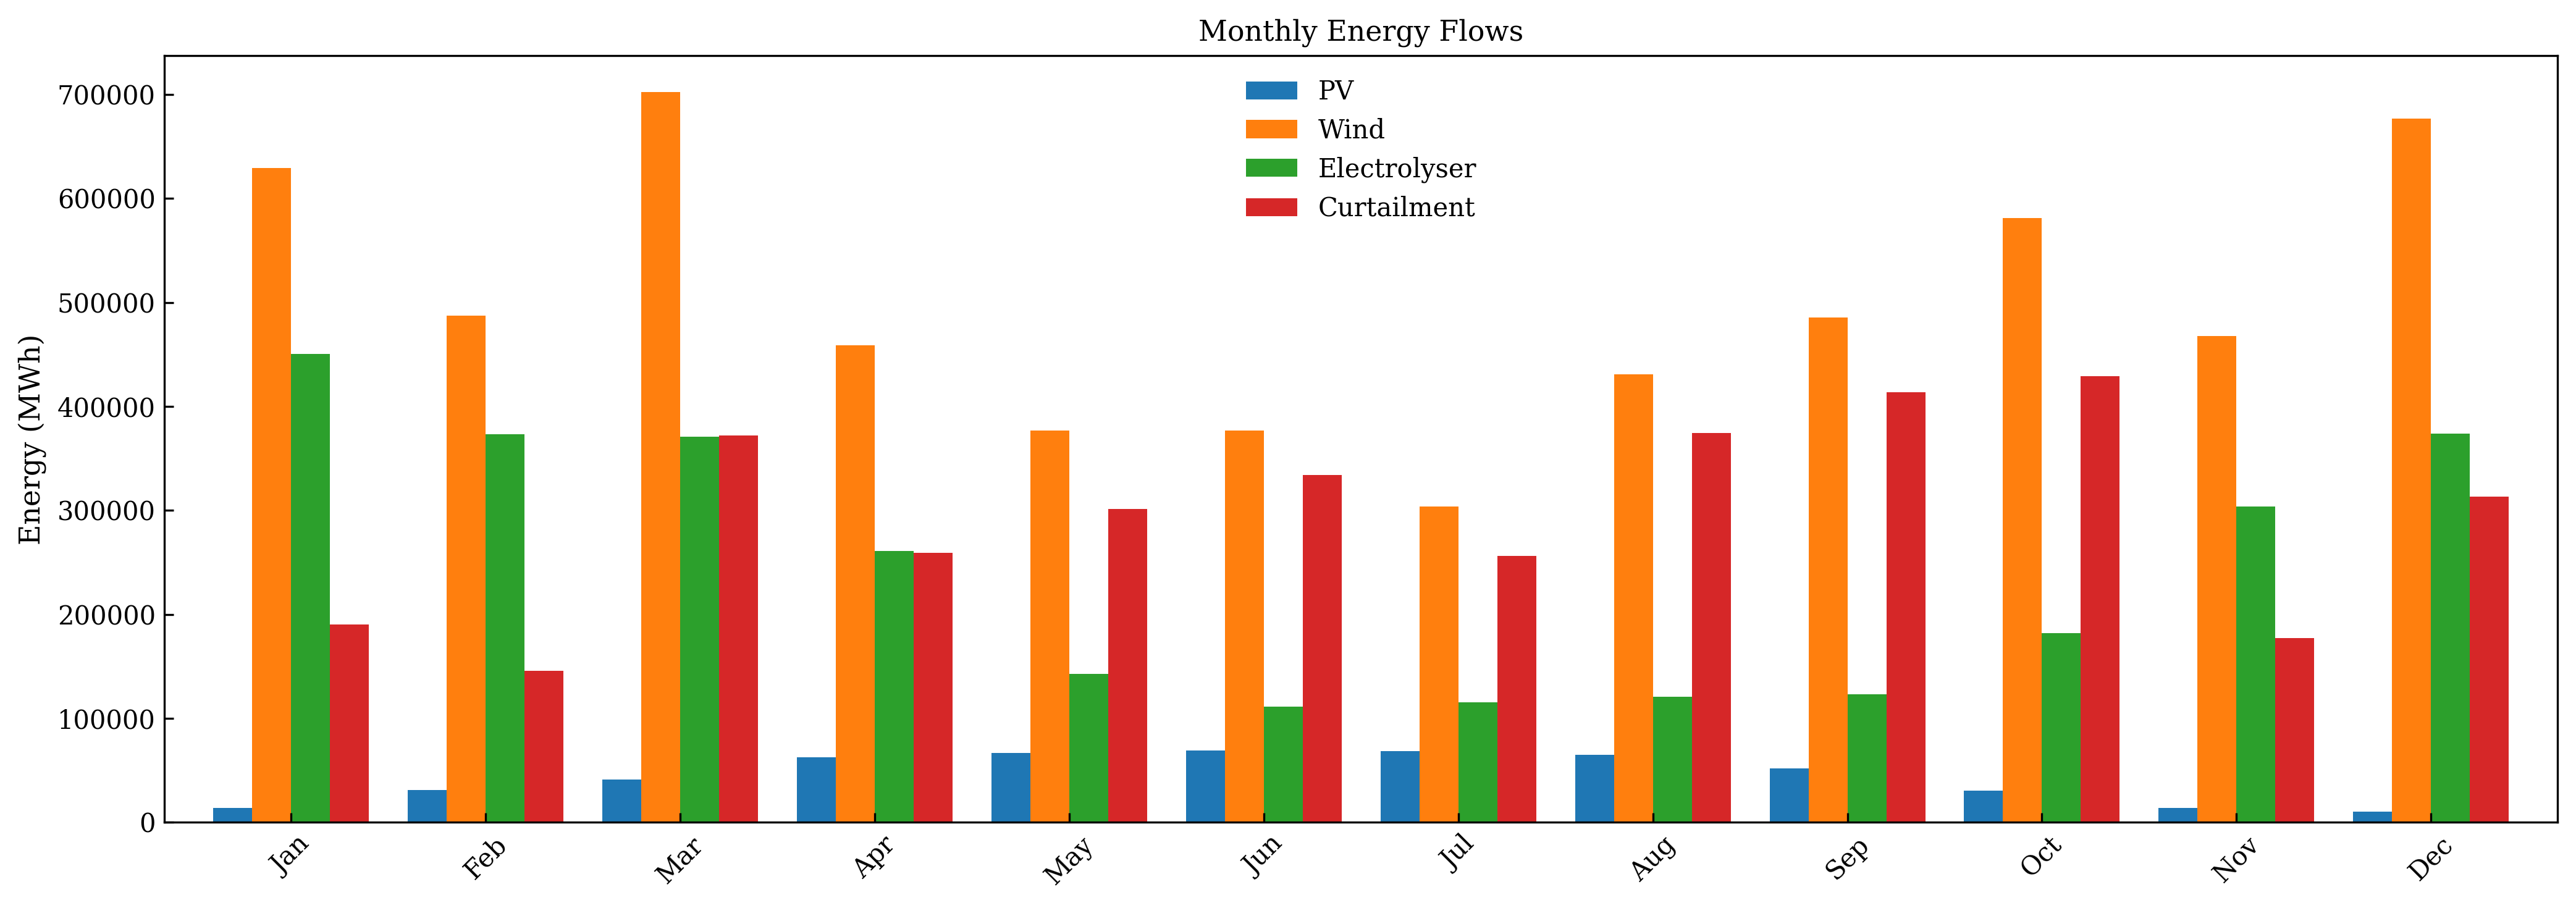

In [ ]:
monthly = pd.DataFrame({
    "PV":          pv_flow.values,
    "Wind":        wind_flow.values,
    "Electrolyser":el_input.values,
    "Curtailment": curtailment.values,
    "H2 Demand":   h2_demand_ts.values,
}, index=idx).resample("ME").sum()

fig, ax = plt.subplots(figsize=(14, 5))
monthly[["PV", "Wind", "Electrolyser", "Curtailment"]].plot(
    kind="bar", ax=ax, width=0.8
)
ax.set_title("Monthly Energy Flows")
ax.set_ylabel("Energy (MWh)")
ax.set_xlabel("")
ax.set_xticklabels([d.strftime("%b") for d in monthly.index], rotation=45)
ax.legend(loc="best")
plt.tight_layout()
#plt.savefig("CAVERN_monthly_flows.png", dpi=150)
plt.show()

PLOT 2 — Sample week: hourly dispatch

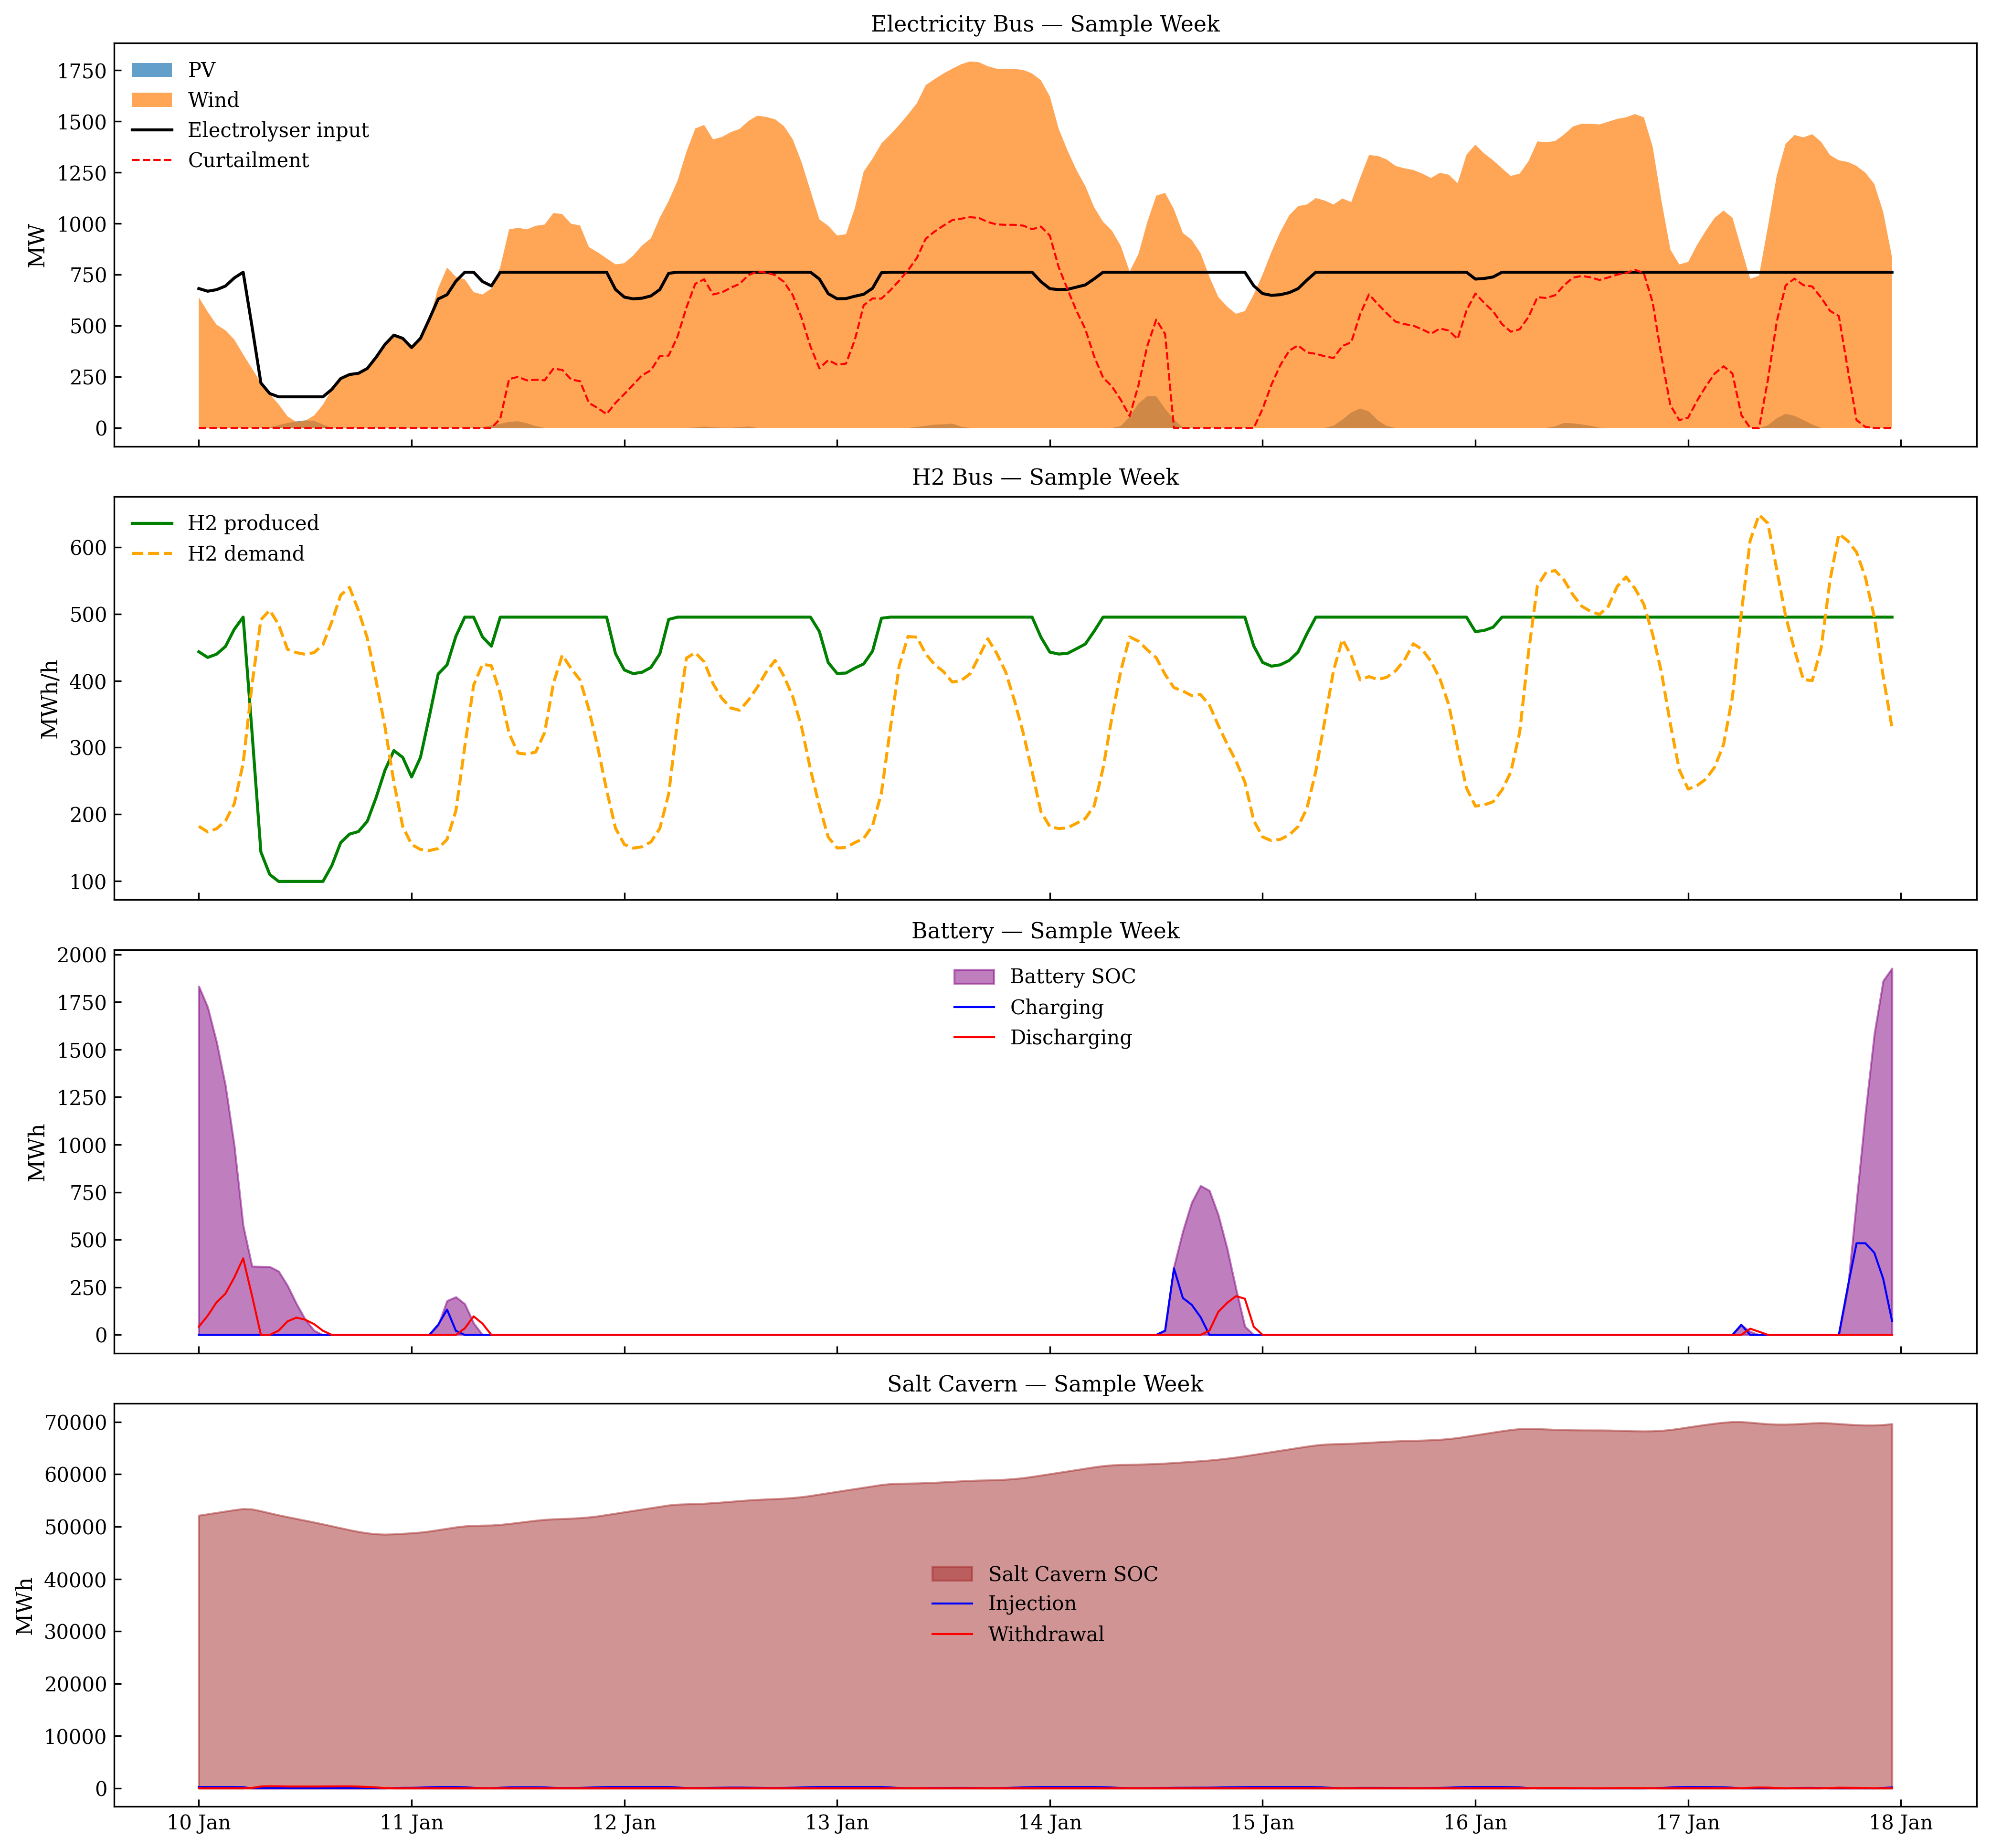

In [ ]:

# Pick a representative summer week (July)
week_start = "2023-07-10"
week_end   = "2023-07-17"
sl = slice("2023-01-10", "2023-01-17")

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

# Electricity bus
axes[0].fill_between(pv_flow.loc[sl].index,   pv_flow.loc[sl].values,   label="PV",   alpha=0.7)
axes[0].fill_between(wind_flow.loc[sl].index, wind_flow.loc[sl].values, label="Wind", alpha=0.7)
axes[0].plot(el_input.loc[sl].index,    el_input.loc[sl].values,    label="Electrolyser input", color="black", lw=1.5)
axes[0].plot(curtailment.loc[sl].index, curtailment.loc[sl].values, label="Curtailment",        color="red",   lw=1, ls="--")
axes[0].set_ylabel("MW")
axes[0].set_title("Electricity Bus — Sample Week")
axes[0].legend(loc="best")

# H2 bus
axes[1].plot(el_output.loc[sl].index,    el_output.loc[sl].values,    label="H2 produced", color="green",  lw=1.5)
axes[1].plot(h2_demand_ts.loc[sl].index, h2_demand_ts.loc[sl].values, label="H2 demand",   color="orange", lw=1.5, ls="--")
axes[1].set_ylabel("MWh/h")
axes[1].set_title("H2 Bus — Sample Week")
axes[1].legend(loc="best")

# Battery SOC
axes[2].fill_between(battery_soc.loc[sl].index, battery_soc.loc[sl].values, alpha=0.5, color="purple", label="Battery SOC")
axes[2].plot(bat_charge.loc[sl].index,    bat_charge.loc[sl].values,    label="Charging",    color="blue", lw=1)
axes[2].plot(bat_discharge.loc[sl].index, bat_discharge.loc[sl].values, label="Discharging", color="red",  lw=1)
axes[2].set_ylabel("MWh")
axes[2].set_title("Battery — Sample Week")
axes[2].legend(loc="best")

# Salt cavern SOC
axes[3].fill_between(saltcavern_soc.loc[sl].index, saltcavern_soc.loc[sl].values, alpha=0.5, color="brown", label="Salt Cavern SOC")
axes[3].plot(saltcavern_charge.loc[sl].index,    saltcavern_charge.loc[sl].values,    label="Injection",  color="blue", lw=1)
axes[3].plot(saltcavern_discharge.loc[sl].index, saltcavern_discharge.loc[sl].values, label="Withdrawal", color="red",  lw=1)
axes[3].set_ylabel("MWh")
axes[3].set_title("Salt Cavern — Sample Week")
axes[3].legend(loc="best")

axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
#plt.savefig("CAVERN_sample_week_dispatch.png", dpi=150)
plt.show()



PLOT 3 — Full year electrolyser load duration curve

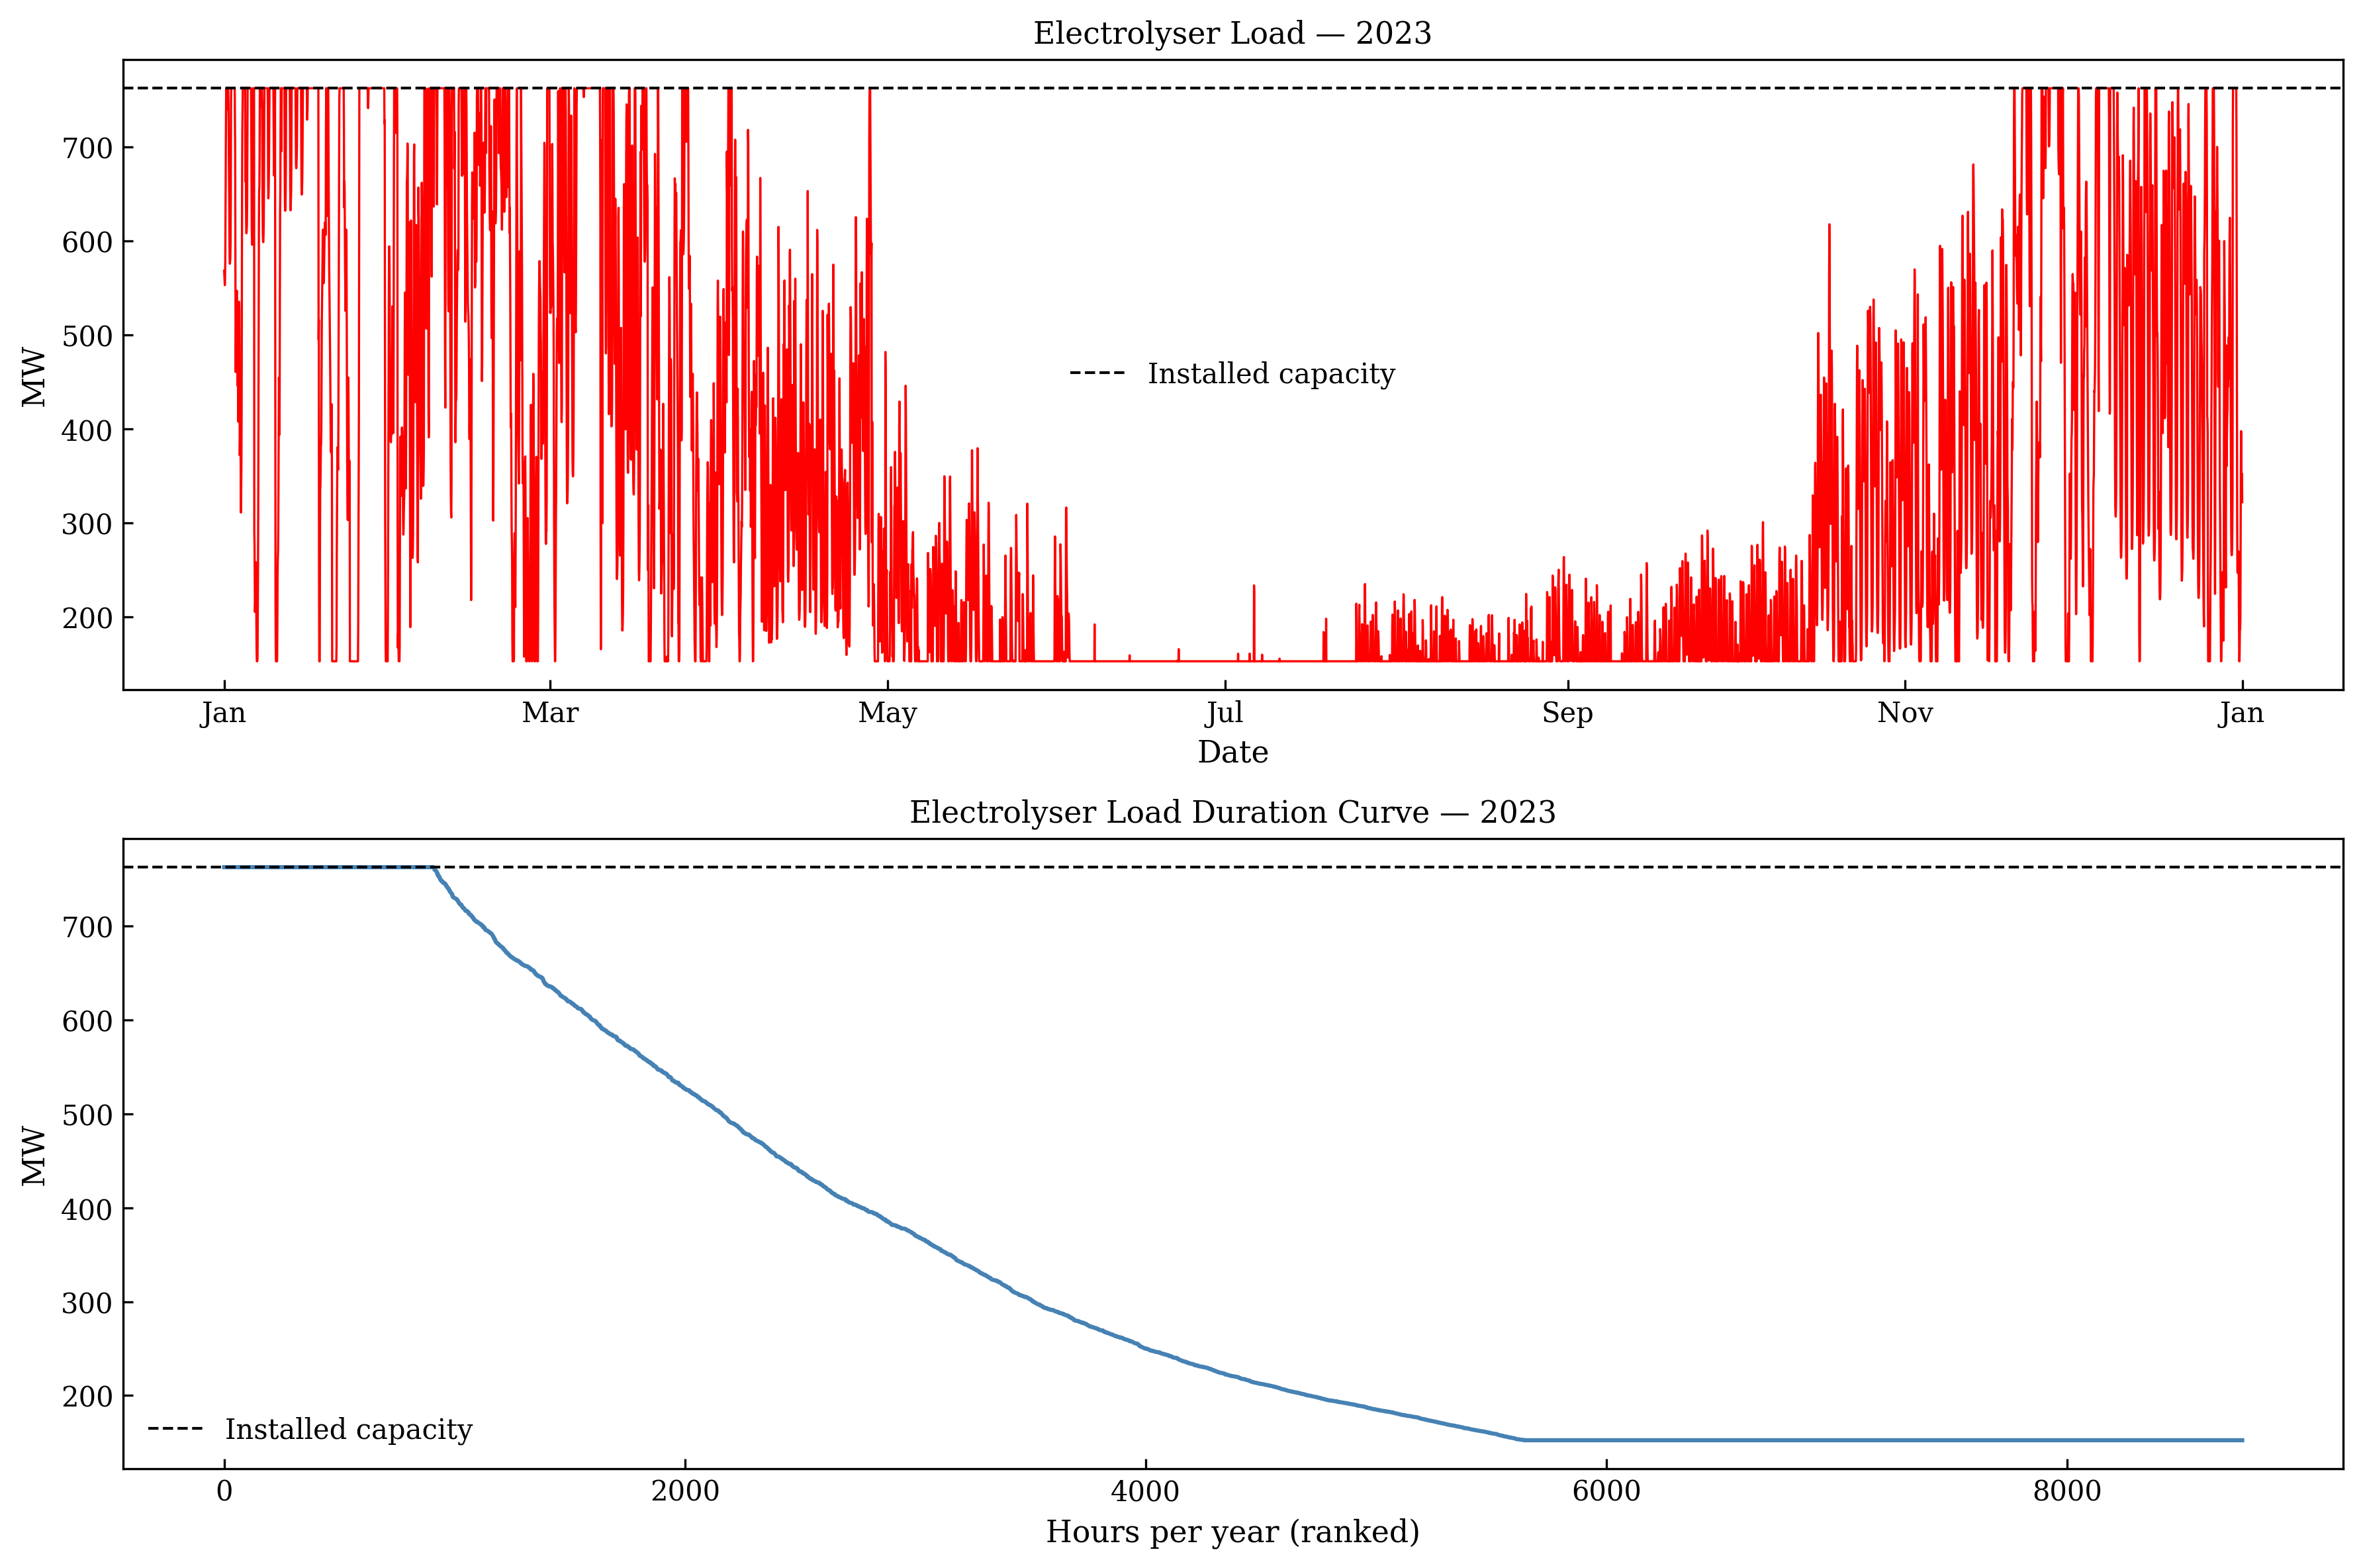

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Top: chronological electrolyser load across 2023
axes[0].plot(el_input.index, el_input.values, color="red", lw=0.8)
axes[0].axhline(capacity_electrolyser_input, color="black", ls="--", lw=1, label="Installed capacity")
axes[0].set_title("Electrolyser Load — 2023")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("MW")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].legend()

# Bottom: load duration curve
sorted_load = el_input.sort_values(ascending=False).values
axes[1].plot(sorted_load, color="steelblue", lw=1.5)
axes[1].axhline(capacity_electrolyser_input, color="black", ls="--", lw=1, label="Installed capacity")
axes[1].set_title("Electrolyser Load Duration Curve — 2023")
axes[1].set_xlabel("Hours per year (ranked)")
axes[1].set_ylabel("MW")
axes[1].legend()

plt.tight_layout()
#plt.savefig("CAVERN_load_duration_curve.png", dpi=150)
plt.show()

PLOT 4 — Full year Battery SOC

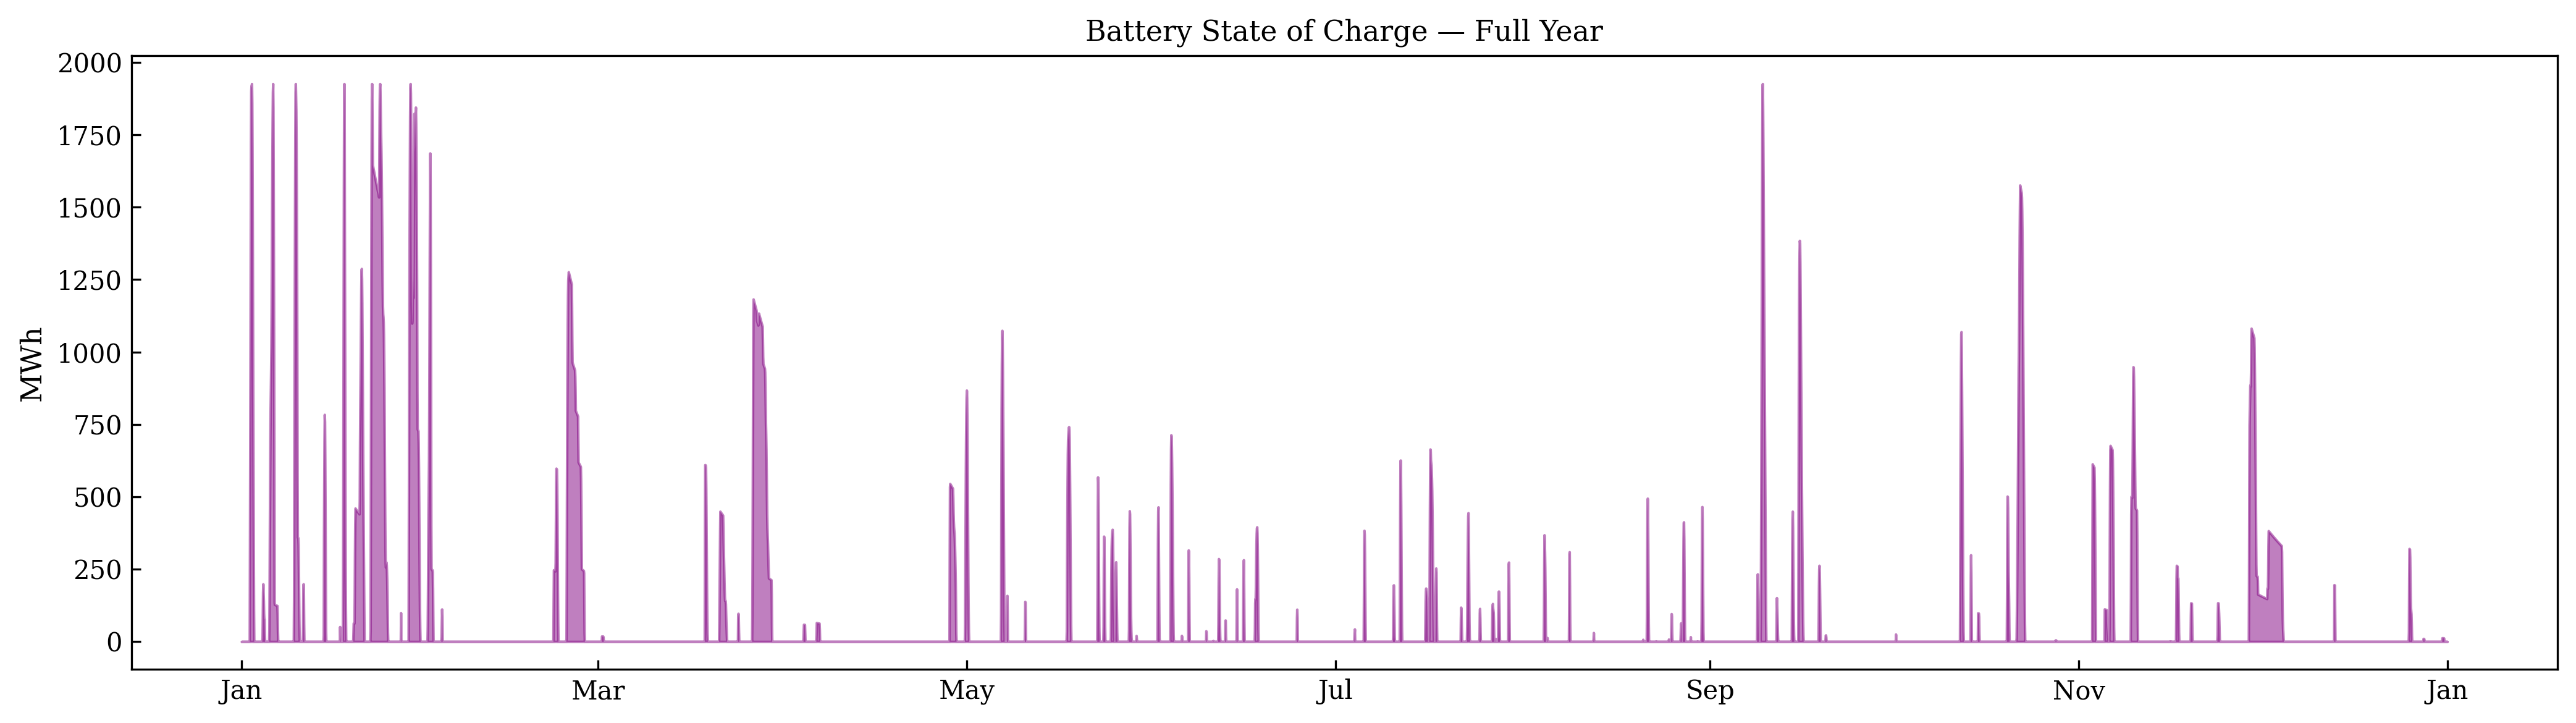

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(battery_soc.index, battery_soc.values, alpha=0.5, color="purple")
ax.set_title("Battery State of Charge — Full Year")
ax.set_ylabel("MWh")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
#plt.savefig("CAVERN_battery_soc_year.png", dpi=150)
plt.show()

PLOT 5 - Full year Salt Cavern SOC

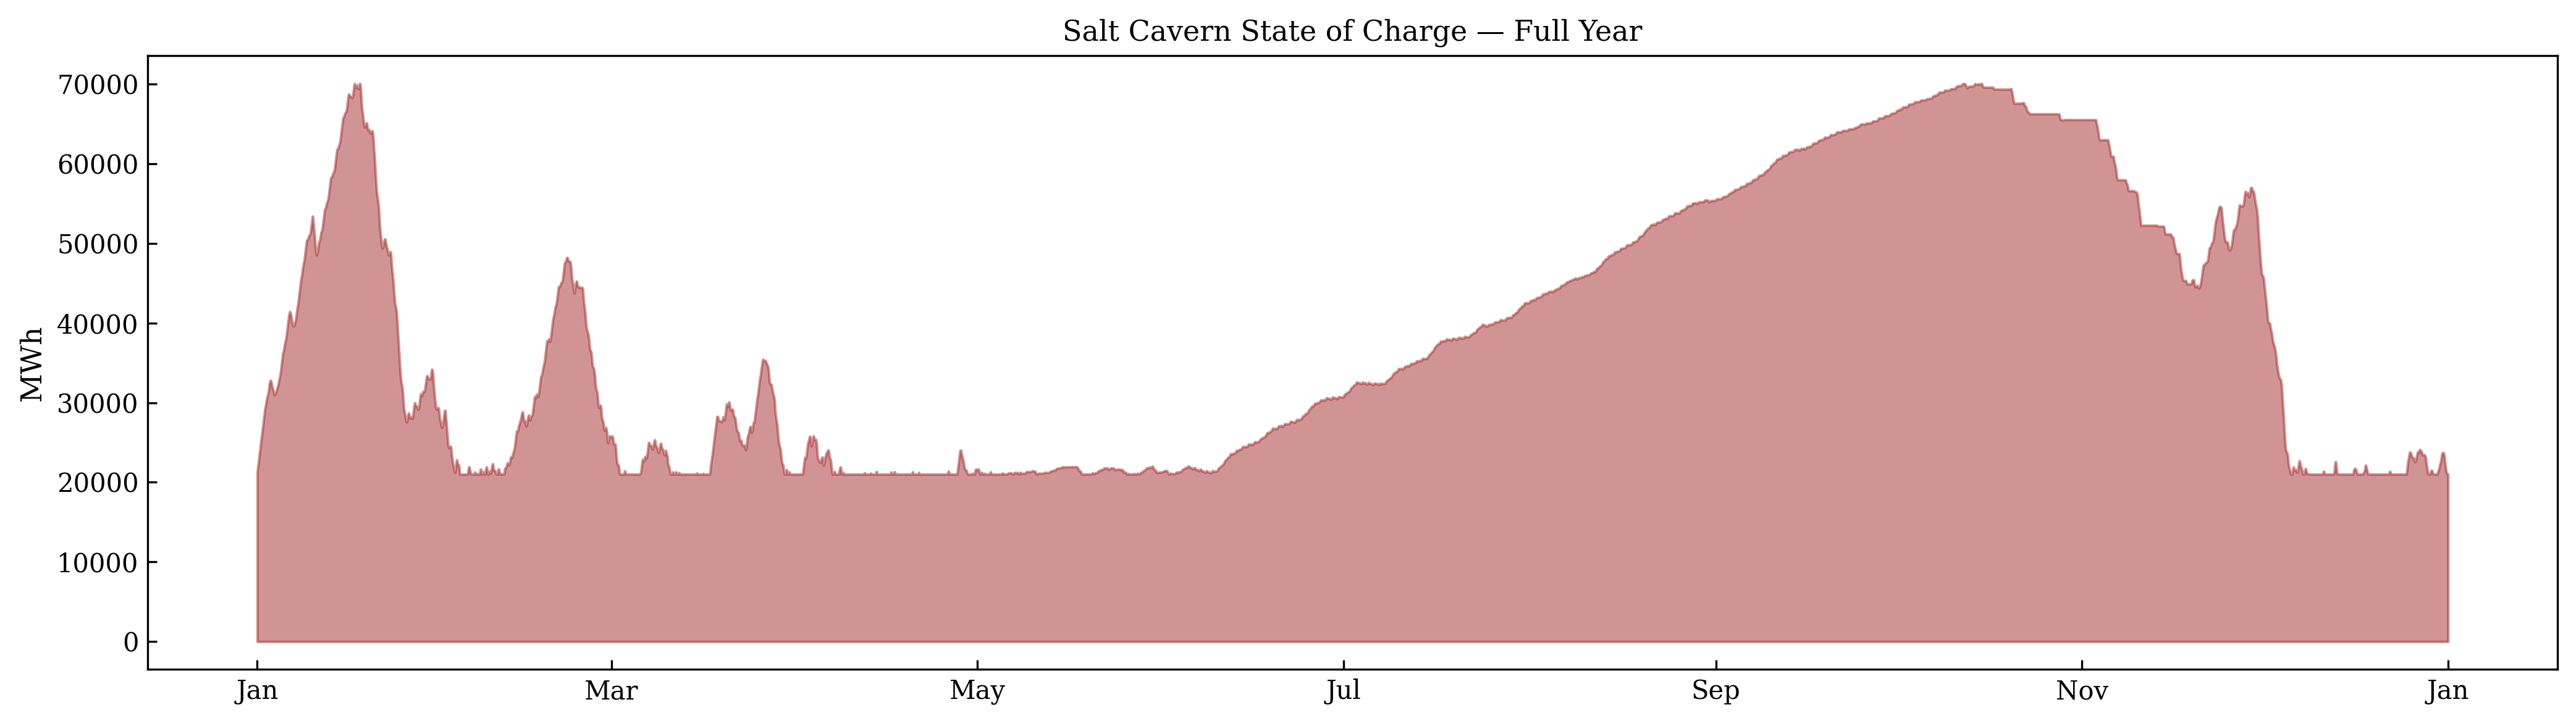

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(saltcavern_soc.index, saltcavern_soc.values, alpha=0.5, color="brown")
ax.set_title("Salt Cavern State of Charge — Full Year")
ax.set_ylabel("MWh")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
#plt.savefig("CAVERN_saltcavern_soc_year.png", dpi=150)
plt.show()


TECHNO-ECONOMICS

 PLOT 6 — Sensitivity: PV vs Wind installed capacity, cost and LCOH2 heatmaps

In [37]:
# STILL TO DO

LCOH2 Calculation

In [38]:
total_cost = model.objective()

total_h2_mwh = el_output.sum()
total_h2_kg  = total_h2_mwh / par.H2_CALORIFIC_VALUE_LHV

lcoh2_mwh = total_cost / total_h2_mwh
lcoh2_kg  = total_cost / total_h2_kg

print("=" * 52)
print("  LCOH2 RESULTS")
print("=" * 52)
print(f"  Total H2 produced  : {total_h2_mwh:>12.1f} MWh_H2/yr")
print(f"  Total H2 produced  : {total_h2_kg:>12.1f} kg_H2/yr")
print(f"  Total system cost  : {total_cost:>12.0f} €/yr")
print(f"  LCOH2              : {lcoh2_mwh:>12.2f} €/MWh_H2")
print(f"  LCOH2              : {lcoh2_kg:>12.2f} €/kg_H2")
print("=" * 52)

# ── Cost breakdown — manual cross-check ──────────────────────────────────────
ep_costs_map = {
    "pv": (
        economics.annuity(par.PV_CAPEX_PANELS, par.PV_LIFETIME_SYSTEM, par.WACC)
        + economics.annuity(par.PV_CAPEX_INVERTER, par.PV_LIFETIME_SYSTEM, par.WACC, u=par.PV_LIFETIME_INVERTER)
        + par.PV_OPEX
    ),
    "wind": (
        economics.annuity(par.WIND_CAPEX, par.WIND_LIFETIME_SYSTEM, par.WACC)
        + par.WIND_OPEX
    ),
    "electrolyser": (
        economics.annuity(par.ELECTROLYSER_CAPEX_SYSTEM, par.ELECTROLYSER_LIFETIME_SYSTEM, par.WACC)
        + economics.annuity(par.ELECTROLYSER_CAPEX_STACK, par.ELECTROLYSER_LIFETIME_SYSTEM, par.WACC, u=par.ELECTROLYSER_LIFETIME_STACK)
        + par.ELECTROLYSER_OPEX
    ),
    "battery_energy": (
        economics.annuity(par.BATTERY_CAPEX_SYSTEM, par.BATTERY_LIFETIME_SYSTEM, par.WACC)
        + economics.annuity(par.BATTERY_CAPEX_BATTERY_PACK, par.BATTERY_LIFETIME_SYSTEM, par.WACC, u=par.BATTERY_LIFETIME_BATTERY_PACK)
    ),
    "battery_power": par.BATTERY_OPEX_FIX,
    "saltcavern_energy": (
        economics.annuity(par.SALTCAVERN_CAPEX, par.SALTCAVERN_LIFETIME, par.WACC)
        + economics.annuity(par.SALTCAVERN_CAPEX_CUSHION_GAS, par.SALTCAVERN_LIFETIME, par.WACC)
        + par.SALTCAVERN_OPEX
    ),
    "saltcavern_compressor": economics.annuity(
        par.SALTCAVERN_CAPEX_COMPRESSOR, par.SALTCAVERN_LIFETIME, par.WACC,
        u=par.SALTCAVERN_LIFETIME_COMPRESSOR
    ),
}

invest_sizes = {
    "pv":                   results[(pv, bus_electricity)]["scalars"]["invest"],
    "wind":                 results[(wind, bus_electricity)]["scalars"]["invest"],
    "electrolyser":         results[(bus_electricity, electrolyser)]["scalars"]["invest"],
    "battery_energy":       results[(battery, None)]["scalars"]["invest"],
    "battery_power":        results[(bus_electricity, battery)]["scalars"]["invest"],
    "saltcavern_energy":    results[(saltcavern, None)]["scalars"]["invest"],
    "saltcavern_compressor":results[(bus_H2, saltcavern)]["scalars"]["invest"],
}

variable_costs_total = {
    "battery_charge":       (bat_charge   * par.BATTERY_OPEX_VAR / 2).sum(),
    "battery_discharge":    (bat_discharge * par.BATTERY_OPEX_VAR / 2).sum(),
    "saltcavern_compress":  (saltcavern_charge * par.SALTCAVERN_OPEX_COMPRESSOR).sum(),
}

print("\n" + "=" * 55)
print("  COST BREAKDOWN")
print("=" * 55)
print(f"\n  {'Component':<35} {'Size':>10}  {'Cost (€/yr)':>12}")
print(f"  {'-'*57}")
total_manual = 0
for key in ep_costs_map:
    size = invest_sizes[key]
    cost = ep_costs_map[key] * size
    total_manual += cost
    unit = "MWh" if "energy" in key else "MW"
    print(f"  {key:<35} {size:>8.1f} {unit}  {cost:>12.0f}")

print(f"\n  Variable costs:")
for key, cost in variable_costs_total.items():
    total_manual += cost
    print(f"  {key:<35}            {cost:>12.0f}")

print(f"\n  {'Manual total':<35}            {total_manual:>12.0f}")
print(f"  {'model.objective()':<35}            {total_cost:>12.0f}")
print(f"  {'Difference':<35}            {abs(total_manual - total_cost):>12.0f}")
print("=" * 55)

# ── Instantaneous LCOH2 ───────────────────────────────────────────────────────
fixed_cost_per_hour = total_cost / len(el_output)
h2_production_safe  = el_output.replace(0, np.nan)
lcoh2_instantaneous = fixed_cost_per_hour / h2_production_safe



  LCOH2 RESULTS
  Total H2 produced  :    1903944.4 MWh_H2/yr
  Total H2 produced  :   57175508.4 kg_H2/yr
  Total system cost  :    729758432 €/yr
  LCOH2              :       383.29 €/MWh_H2
  LCOH2              :        12.76 €/kg_H2

  COST BREAKDOWN

  Component                                 Size   Cost (€/yr)
  ---------------------------------------------------------
  pv                                     453.2 MW      31285195
  wind                                  1967.1 MW     334543055
  electrolyser                           762.3 MW     199158260
  battery_energy                        1926.6 MWh      94346783
  battery_power                          481.6 MW       3275193
  saltcavern_energy                    70037.4 MWh       6432153
  saltcavern_compressor                  261.8 MW      60609470

  Variable costs:
  battery_charge                                         7689
  battery_discharge                                      6870
  saltcavern_compress       

PLOT 7 — Instantaneous LCOH2 + H2 Demand

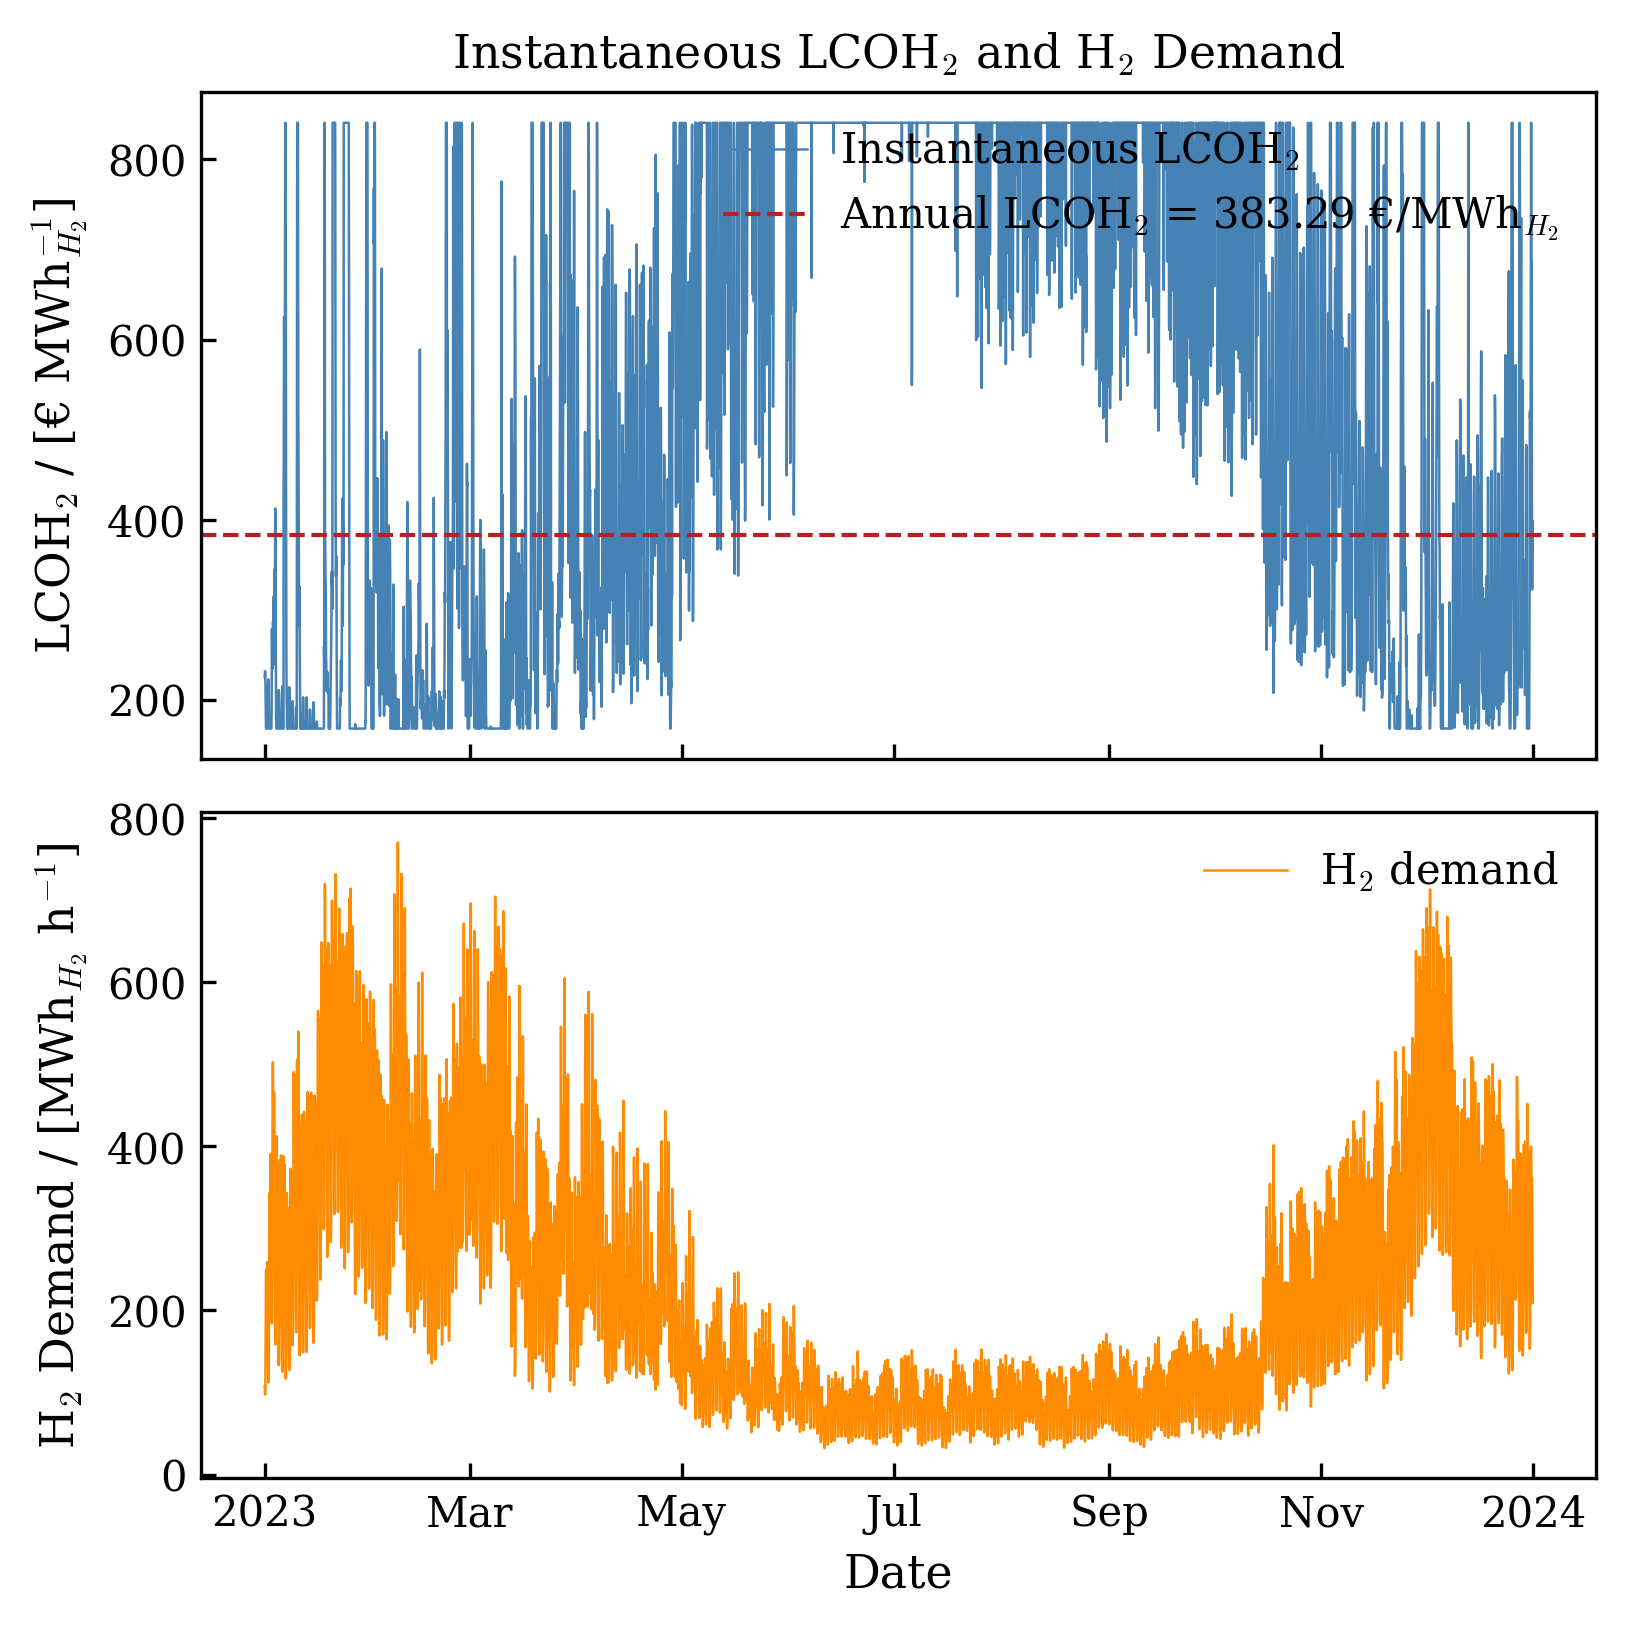

WACC                : 0.07
WIND_LIFETIME_SYSTEM: 20
Wind annuity        : 125,071 €/MW/yr
Wind ep_costs total : 170,071 €/MW/yr


In [ ]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(6, 6),
    sharex=True,
)
fig.subplots_adjust(hspace=0.08)

# ── Top: instantaneous LCOH2 ─────────────────────────────────────────────────
axes[0].plot(
    lcoh2_instantaneous.index, lcoh2_instantaneous.values,
    color="steelblue", linewidth=0.6, label=r"Instantaneous LCOH$_2$"
)
axes[0].axhline(
    lcoh2_mwh,
    color="firebrick", linewidth=1.0, linestyle="--",
    label=rf"Annual LCOH$_2$ = {lcoh2_mwh:.2f} €/MWh$_{{H_2}}$"
)
axes[0].set_ylabel(r"LCOH$_2$ / [€ MWh$_{H_2}^{-1}$]")
axes[0].legend(loc="upper right")
axes[0].set_title(r"Instantaneous LCOH$_2$ and H$_2$ Demand")

# ── Bottom: H2 demand ────────────────────────────────────────────────────────
axes[1].plot(
    h2_demand_ts.index, h2_demand_ts.values,
    color="darkorange", linewidth=0.6, label=r"H$_2$ demand"
)
axes[1].set_ylabel(r"H$_2$ Demand / [MWh$_{H_2}$ h$^{-1}$]")
axes[1].set_xlabel(r"Date")
axes[1].legend(loc="upper right")

# ── X-axis ───────────────────────────────────────────────────────────────────
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(formatter)

figures_path = DATA_DIR.parent / "[03] Figures"
figures_path.mkdir(exist_ok=True)
#(figures_path / "lcoh2_instantaneous.pdf", bbox_inches="tight")
plt.show()


print(f"WACC                : {par.WACC}")
print(f"WIND_LIFETIME_SYSTEM: {par.WIND_LIFETIME_SYSTEM}")
print(f"Wind annuity        : {economics.annuity(par.WIND_CAPEX, par.WIND_LIFETIME_SYSTEM, par.WACC):,.0f} €/MW/yr")
print(f"Wind ep_costs total : {economics.annuity(par.WIND_CAPEX, par.WIND_LIFETIME_SYSTEM, par.WACC) + par.WIND_OPEX:,.0f} €/MW/yr")



PLOT 8 — Replacement cost overhead for key components

  Component                  No replacement With replacement   Overhead
  PV Inverter                        9,722          11,309     1,586  (16.3%)
  Electrolyser Stack                38,512          99,507    60,995  (158.4%)
  Battery Pack                       6,051          10,365     4,314  (71.3%)
  Salt Cavern Compressor           199,061         231,540    32,480  (16.3%)


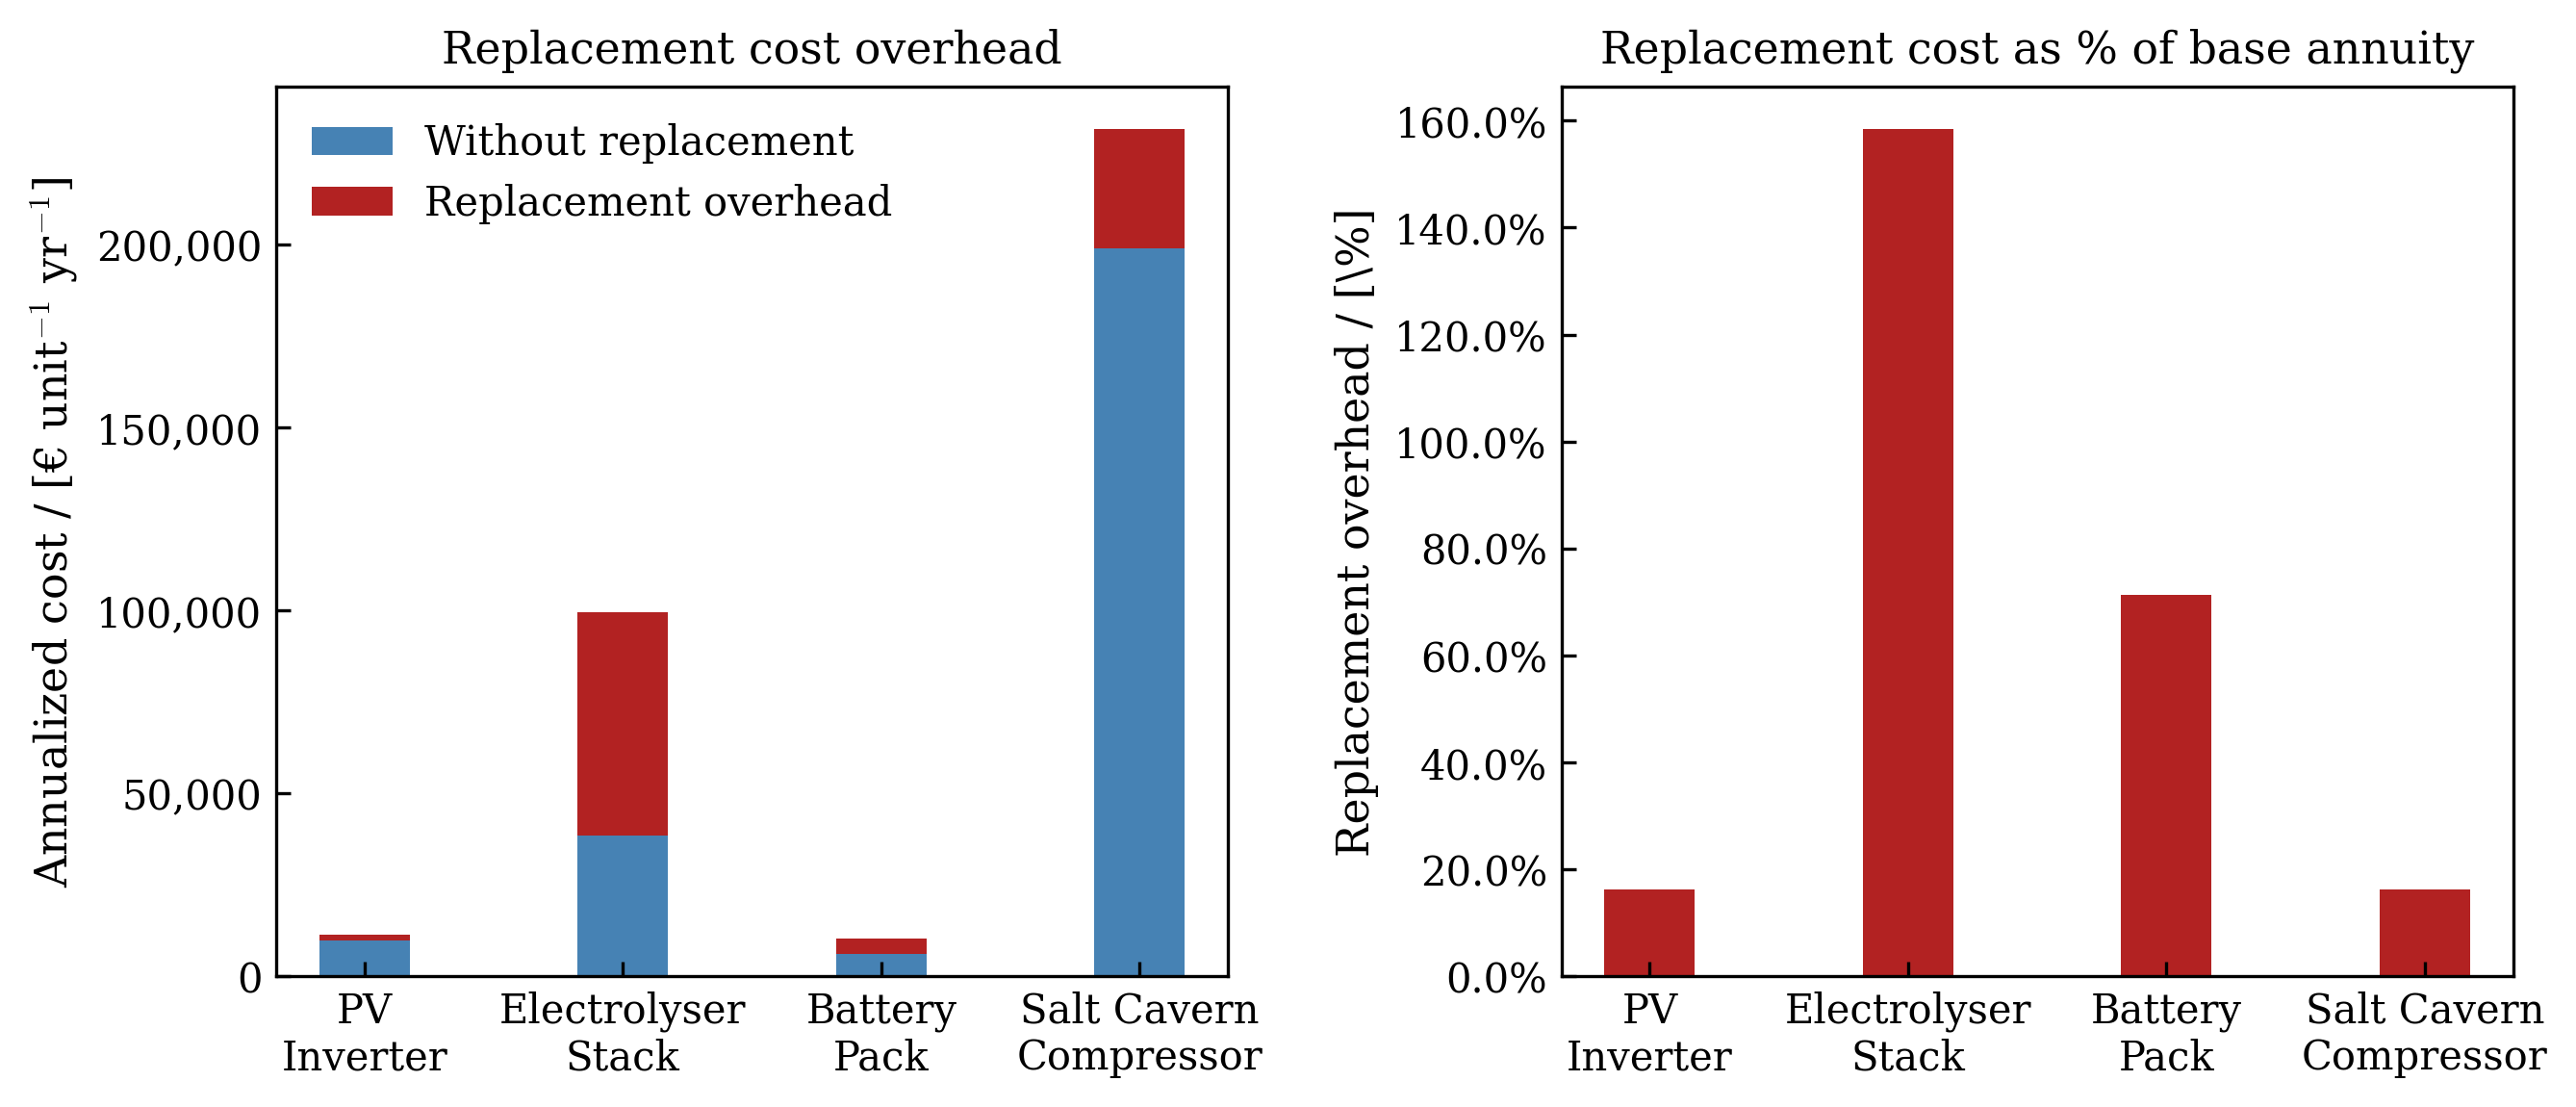

Levelized cost of H2: 383.2876744930289 MWh/yr

  FINANCIAL METRICS
  LCOH2              :     383.29 €/MWh_H2
  Margin             :        8.1 %
  H2 selling price   :     414.33 €/MWh_H2
  Profit per MWh     :      31.05 €/MWh_H2
  Annual revenue     :    788868865 €/yr
  Annual OPEX total  :    130148681 €/yr
  Annual net cashflow:    658720184 €/yr
  Total CAPEX        :   5361493135 €
  Project horizon    :         20 years
  NPV (20 yr)      :    1617.00 M€
  IRR                :      10.67 %
  Payback (simple)   :       8.14 years  (undiscounted)
  Payback (discounted):     12.47 years  (NPV zero-crossing)


In [ ]:
components = {
    "PV\nInverter": {
        "capex":    par.PV_CAPEX_INVERTER,
        "n":        par.PV_LIFETIME_SYSTEM,
        "u":        par.PV_LIFETIME_INVERTER,
        "unit":     "€/MW/yr",
    },
    "Electrolyser\nStack": {
        "capex":    par.ELECTROLYSER_CAPEX_STACK,
        "n":        par.ELECTROLYSER_LIFETIME_SYSTEM,
        "u":        par.ELECTROLYSER_LIFETIME_STACK,
        "unit":     "€/MW/yr",
    },
    "Battery\nPack": {
        "capex":    par.BATTERY_CAPEX_BATTERY_PACK,
        "n":        par.BATTERY_LIFETIME_SYSTEM,
        "u":        par.BATTERY_LIFETIME_BATTERY_PACK,
        "unit":     "€/MWh/yr",
    },
    "Salt Cavern\nCompressor": {
        "capex":    par.SALTCAVERN_CAPEX_COMPRESSOR,
        "n":        par.SALTCAVERN_LIFETIME,
        "u":        par.SALTCAVERN_LIFETIME_COMPRESSOR,
        "unit":     "€/MW/yr",
    },
}

# ── Compute annuities with and without replacement ────────────────────────────
labels, without_replacement, with_replacement, overhead = [], [], [], []

for name, c in components.items():
    a_without = economics.annuity(c["capex"], c["n"], par.WACC)          # u = n, no replacement
    a_with    = economics.annuity(c["capex"], c["n"], par.WACC, u=c["u"])  # with replacement
    labels.append(name)
    without_replacement.append(a_without)
    with_replacement.append(a_with)
    overhead.append(a_with - a_without)

# ── Plot ──────────────────────────────────────────────────────────────────────
x     = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.35)

# Left: stacked bar — base annuity + replacement overhead
axes[0].bar(x, without_replacement, width, label="Without replacement", color="steelblue")
axes[0].bar(x, overhead,            width, label="Replacement overhead", color="firebrick",
            bottom=without_replacement)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel(r"Annualized cost / [€ unit$^{-1}$ yr$^{-1}$]")
axes[0].set_title("Replacement cost overhead")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Right: % overhead relative to no-replacement annuity
pct_overhead = [o / w * 100 for o, w in zip(overhead, without_replacement)]
axes[1].bar(x, pct_overhead, width, color="firebrick")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel(r"Replacement overhead / [\%]")
axes[1].set_title("Replacement cost as % of base annuity")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 68)
print(f"  {'Component':<25} {'No replacement':>15} {'With replacement':>16} {'Overhead':>10}")
print("=" * 68)
for i, name in enumerate(labels):
    print(
        f"  {name.replace(chr(10), ' '):<25}"
        f"  {without_replacement[i]:>13,.0f}"
        f"  {with_replacement[i]:>14,.0f}"
        f"  {overhead[i]:>8,.0f}  ({pct_overhead[i]:.1f}%)"
    )
print("=" * 68)

figures_path = DATA_DIR.parent / "[03] Figures"
figures_path.mkdir(exist_ok=True)
#plt.savefig(figures_path / "replacement_cost_overhead.pdf", bbox_inches="tight")
plt.show()


print("Levelized cost of H2:", lcoh2_mwh, "MWh/yr")



# =============================================================================
# FINANCIAL METRICS — NPV, IRR, Payback, H2 Selling Price
# =============================================================================

# ── H2 selling price ─────────────────────────────────────────────────────────
MARGIN           = par.MARGIN_H2
H2_SELLING_PRICE = lcoh2_mwh / (1 - MARGIN)               # €/MWh_H2

# ── Annual revenue ────────────────────────────────────────────────────────────
annual_revenue   = total_h2_mwh * H2_SELLING_PRICE         # €/yr

# ── Annual variable OPEX (already computed above) ────────────────────────────
annual_var_opex  = sum(variable_costs_total.values())       # €/yr

# ── Annual fixed OPEX (capacity-based, not in annuity for financial model) ───
annual_fixed_opex = (
      invest_sizes["pv"]                      * par.PV_OPEX
    + invest_sizes["wind"]                    * par.WIND_OPEX
    + invest_sizes["electrolyser"]            * par.ELECTROLYSER_OPEX
    + invest_sizes["battery_power"]           * par.BATTERY_OPEX_FIX
    + invest_sizes["saltcavern_energy"]       * par.SALTCAVERN_OPEX
)

annual_cost_total = annual_fixed_opex + annual_var_opex     # €/yr
annual_cashflow   = annual_revenue - annual_cost_total      # €/yr net of OPEX

# ── Total upfront CAPEX (undiscounted, as spent at year 0) ───────────────────
capex_total = (
      invest_sizes["pv"]                      * (par.PV_CAPEX_PANELS + par.PV_CAPEX_INVERTER)
    + invest_sizes["wind"]                    * par.WIND_CAPEX
    + invest_sizes["electrolyser"]            * par.ELECTROLYSER_CAPEX
    + invest_sizes["battery_energy"]          * par.BATTERY_CAPEX
    + invest_sizes["battery_power"]           * par.BATTERY_CAPEX_POWER
    + invest_sizes["saltcavern_energy"]       * par.SALTCAVERN_CAPEX
    + invest_sizes["saltcavern_compressor"]   * par.SALTCAVERN_CAPEX_COMPRESSOR
)

# ── Project horizon ───────────────────────────────────────────────────────────
horizon = max(
    par.PV_LIFETIME_SYSTEM,
    par.WIND_LIFETIME_SYSTEM,
    par.ELECTROLYSER_LIFETIME_SYSTEM,
    par.BATTERY_LIFETIME_SYSTEM,
    par.SALTCAVERN_LIFETIME,
)

# ── Cash flow array ───────────────────────────────────────────────────────────
# Year 0: -CAPEX; years 1..horizon: net annual cashflow
cashflows = np.array([-capex_total] + [annual_cashflow] * horizon)

# ── NPV time series ───────────────────────────────────────────────────────────
years      = np.arange(0, horizon + 1)
npv_series = np.array([
    npf.npv(par.WACC, cashflows[:t + 1])
    for t in range(len(cashflows))
])

# ── Scalar metrics ────────────────────────────────────────────────────────────
npv_final  = npf.npv(par.WACC, cashflows)
irr        = npf.irr(cashflows)

# ── Undiscounted payback: linear interpolation between last negative and first
#    positive cumulative nominal cashflow
cumulative_undiscounted = np.cumsum(cashflows)
payback_idx_simple      = np.where(cumulative_undiscounted >= 0)[0]
if len(payback_idx_simple) > 0:
    t0 = payback_idx_simple[0] - 1                          # last negative year
    t1 = payback_idx_simple[0]                              # first non-negative year
    # linear interpolation: fraction of the year into t1 where crossing occurs
    frac_simple  = -cumulative_undiscounted[t0] / (cumulative_undiscounted[t1] - cumulative_undiscounted[t0])
    payback_simple = t0 + frac_simple                       # fractional year
else:
    payback_simple = None

# ── Discounted payback: linear interpolation between last negative and first  # REMOVE THIS BLOCK to show only simple PBT
#    positive NPV value                                                         # REMOVE
payback_idx_disc = np.where(npv_series >= 0)[0]                                # REMOVE
if len(payback_idx_disc) > 0:                                                  # REMOVE
    t0_d = payback_idx_disc[0] - 1                                             # REMOVE
    t1_d = payback_idx_disc[0]                                                 # REMOVE
    frac_disc        = -npv_series[t0_d] / (npv_series[t1_d] - npv_series[t0_d])  # REMOVE
    payback_discounted = t0_d + frac_disc                                      # REMOVE
else:                                                                           # REMOVE
    payback_discounted = None                                                   # REMOVE

print("\n" + "=" * 52)
print("  FINANCIAL METRICS")
print("=" * 52)
print(f"  LCOH2              : {lcoh2_mwh:>10.2f} €/MWh_H2")
print(f"  Margin             : {MARGIN*100:>10.1f} %")
print(f"  H2 selling price   : {H2_SELLING_PRICE:>10.2f} €/MWh_H2")
print(f"  Profit per MWh     : {H2_SELLING_PRICE - lcoh2_mwh:>10.2f} €/MWh_H2")
print(f"  Annual revenue     : {annual_revenue:>12.0f} €/yr")
print(f"  Annual OPEX total  : {annual_cost_total:>12.0f} €/yr")
print(f"  Annual net cashflow: {annual_cashflow:>12.0f} €/yr")
print(f"  Total CAPEX        : {capex_total:>12.0f} €")
print(f"  Project horizon    : {horizon:>10} years")
print(f"  NPV ({horizon} yr)      : {npv_final/1e6:>10.2f} M€")
print(f"  IRR                : {irr*100:>10.2f} %")
if payback_simple is not None:
    print(f"  Payback (simple)   : {payback_simple:>10.2f} years  (undiscounted)")
else:
    print(f"  Payback (simple)   :    >{horizon} years (not recovered)")
if payback_discounted is not None:                                               # REMOVE THIS BLOCK to show only simple PBT
    print(f"  Payback (discounted): {payback_discounted:>9.2f} years  (NPV zero-crossing)")  # REMOVE
else:                                                                            # REMOVE
    print(f"  Payback (discounted):   >{horizon} years (not recovered)")        # REMOVE
print("=" * 52)



PLOT 9 — NPV evolution over project lifetime

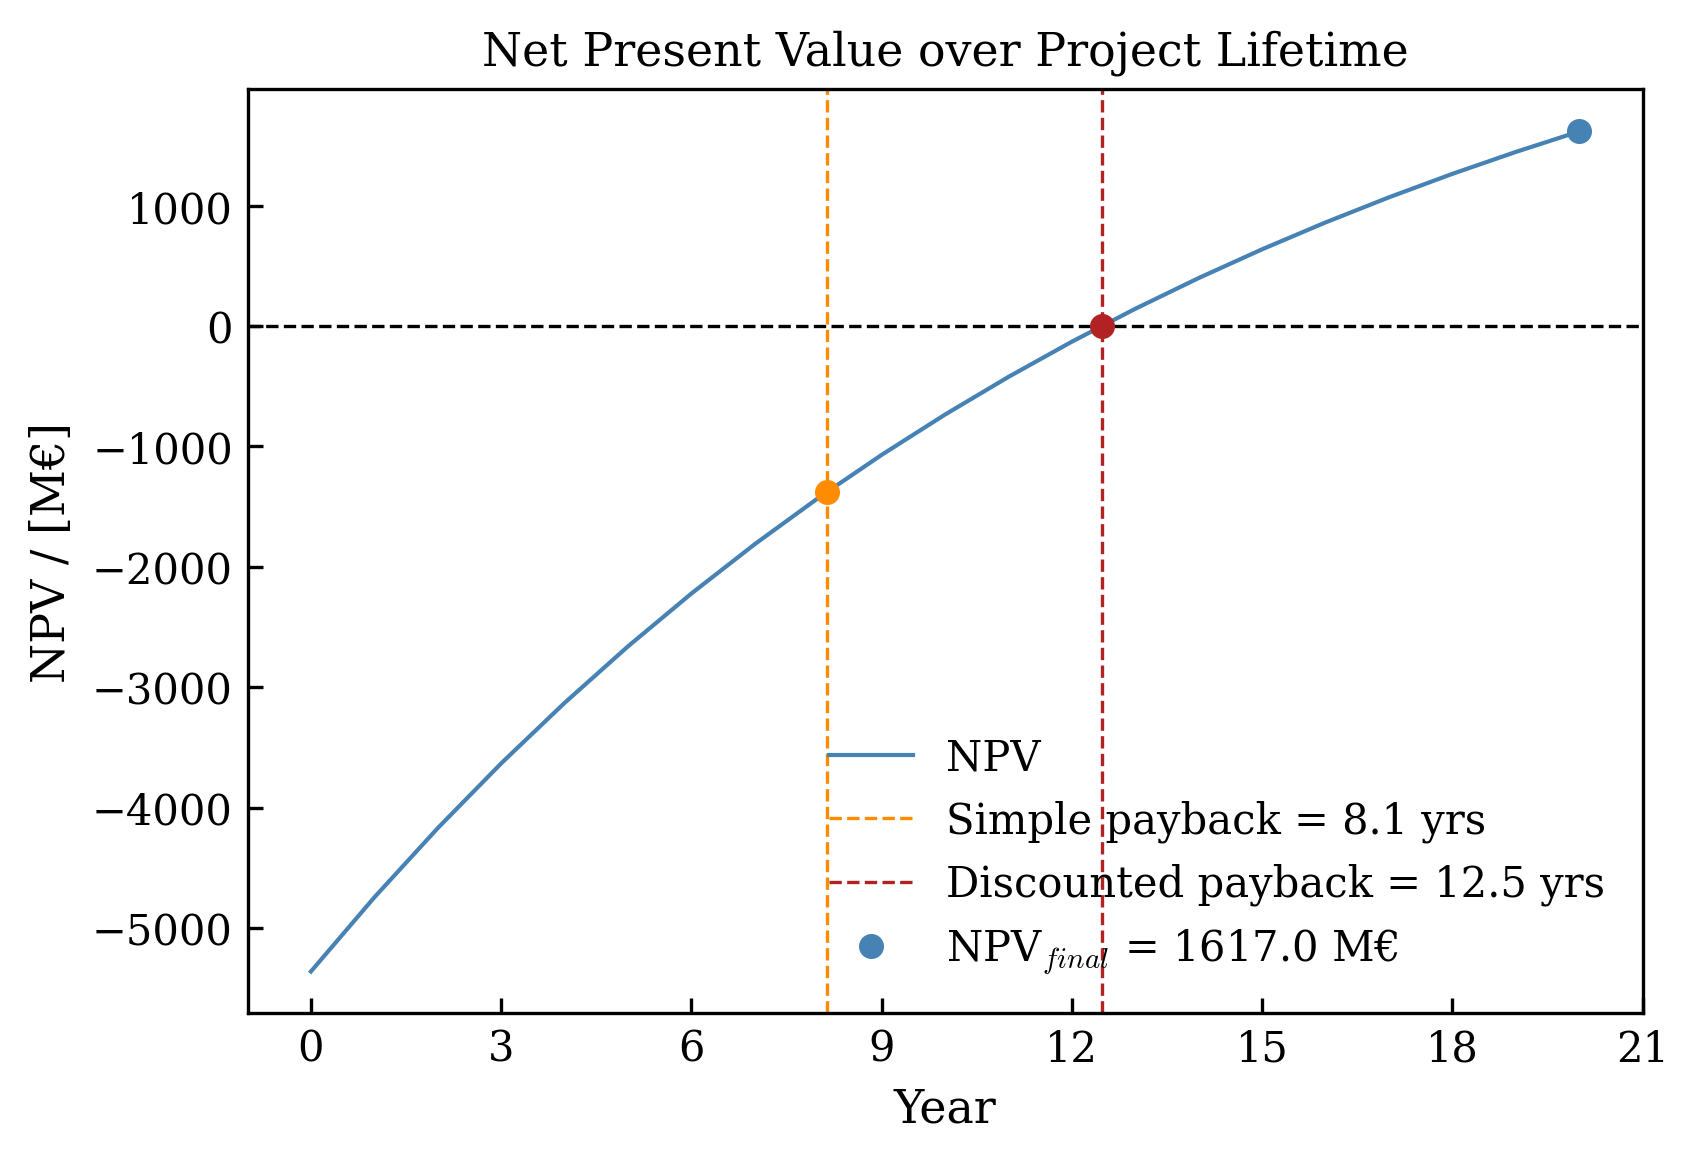

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(years, npv_series / 1e6, color="steelblue", linewidth=1.0, label="NPV")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Simple (undiscounted) payback — interpolated crossing, marker on NPV curve
if payback_simple is not None:
    npv_at_simple = np.interp(payback_simple, years, npv_series / 1e6)
    ax.axvline(
        payback_simple, color="darkorange", linewidth=0.8, linestyle="--",
        label=f"Simple payback = {payback_simple:.1f} yrs"
    )
    ax.plot(payback_simple, npv_at_simple, "o", color="darkorange", markersize=5)

# Discounted payback — interpolated zero-crossing, marker at y=0              # REMOVE THIS BLOCK to show only simple PBT
if payback_discounted is not None:                                              # REMOVE
    ax.axvline(                                                                 # REMOVE
        payback_discounted, color="firebrick", linewidth=0.8, linestyle="--",  # REMOVE
        label=f"Discounted payback = {payback_discounted:.1f} yrs"             # REMOVE
    )                                                                           # REMOVE
    ax.plot(payback_discounted, 0, "o", color="firebrick", markersize=5)       # REMOVE

ax.plot(
    horizon, npv_final / 1e6, "o", color="steelblue", markersize=5,
    label=f"NPV$_{{final}}$ = {npv_final/1e6:.1f} M€"
)

ax.set_xlabel(r"Year")
ax.set_ylabel(r"NPV / [M€]")
ax.set_title(r"Net Present Value over Project Lifetime")
ax.legend(loc="best")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

#plt.savefig(figures_path / "npv_evolution.pdf", bbox_inches="tight")
plt.show()